![display relevant image here](path/url/to/image)

# Loan Approval Risk Modelling for FinTech Innovations

## Machine Learning Model for Loan Approval Decision Support

This notebook follows the CRISP-DM framework and builds a complete classification pipeline for loan approval decision support using the supplied loan-risk dataset.

## Overview

**Bottom Line Up Front (BLUF):** This notebook develops a supervised classification model to support loan approval decisions. The key business issue is asymmetric error cost: approving a bad loan costs an estimated **$50,000**, while rejecting a good applicant costs an estimated **$8,000**. Because false approvals are more expensive, the final model is selected using both statistical metrics and a custom business cost metric.

The notebook story is: understand the lending problem, inspect data quality, engineer risk-related features, build reproducible preprocessing pipelines, compare multiple models, tune the best model, optimize the decision threshold, and translate model performance into business recommendations.

# Business Understanding

## 1. Business Context

FinTech Innovations wants to modernize a manual loan approval process. Manual review can be slow, inconsistent, and difficult to scale. A data-driven model can help standardize decision support by using borrower demographics, credit behaviour, loan characteristics, income, debt, assets, and repayment indicators.

### Stakeholders

| Stakeholder | Need |
|---|---|
| Loan officers | Consistent, explainable decision support. |
| Risk analytics team | Robust model with defensible validation. |
| Senior management | Lower losses, faster decisions, better profitability. |
| Compliance teams | Transparent documentation and explainable model logic. |
| Applicants | Faster and more consistent application outcomes. |

### Error implications

- **False Positive:** model approves a borrower who should be declined. Business loss = **$50,000**.
- **False Negative:** model rejects a borrower who would have been profitable. Business loss = **$8,000**.

The false-positive cost is **6.25 times** the false-negative cost, so we cannot rely on accuracy alone. The model needs to control expensive false approvals while still identifying creditworthy customers.

## 2. Classification or Regression?

The dataset contains a binary target named `LoanApproved`, so this notebook uses **classification**. The goal is to predict whether a loan should be approved or not.

A regression approach using `RiskScore` could be useful for internal risk scoring, but classification is more directly aligned with the operational decision: **approve or decline**.

### Success metrics

The notebook uses:

1. **Accuracy** for overall correctness.
2. **Precision** to measure reliability of predicted approvals.
3. **Recall** to identify how many truly approved applicants are captured.
4. **F1-score** to balance precision and recall.
5. **ROC-AUC** to measure separation ability across thresholds.
6. **Custom business cost** to convert model errors into dollar impact.

Custom cost formula:

```text
Business Cost = (False Positives × 50,000) + (False Negatives × 8,000)
```

# Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
RANDOM_STATE = 42

# Data Understanding

## 3. Load the Dataset

The code below searches for the CSV file in the same folder as the notebook. This avoids hardcoding your Windows path and makes the notebook easier to submit. Ensure one of these files is in the same folder as the notebook:

- `financial_loan_data.csv`
- `Loan.csv`
- `financial_loan_risk.csv`

In [2]:
current_folder = Path.cwd()
candidate_files = ["financial_loan_data.csv", "Loan.csv", "financial_loan_risk.csv"]

csv_path = None
for file_name in candidate_files:
    path = current_folder / file_name
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("Place financial_loan_data.csv, Loan.csv, or financial_loan_risk.csv in the same folder as this notebook.")

print(f"Dataset loaded from: {csv_path}")
df = pd.read_csv(csv_path)
display(df.head())
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded from: c:\Users\injuguna\Desktop\MORINGA\Module 4 Assignment\Summative_09_08\Final output\financial_loan_data.csv


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


Rows: 20,000
Columns: 35


**From above, the dataset was successfully loaded.**

## Basic Data Characteristics

This section checks column names, data types, basic descriptive statistics, duplicate records, and general structure. This is important because modelling requires clean and correctly typed data.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T)

Column names:
['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Data types:


,dtype
Age,int64
AnnualIncome,object
CreditScore,int64
EmploymentStatus,object
EducationLevel,object
Experience,int64
LoanAmount,int64
LoanDuration,int64
MaritalStatus,object
NumberOfDependents,int64



Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


## Above Results Interpretation: Data Structure and Quality Assessment

### Overview

The dataset structure: column names, data types, duplicate checks, and descriptive statistics. This step is critical because machine learning algorithms require clean, consistent, and appropriately typed data before model training can begin.

#### 1. Dataset Structure

The dataset contains **35 variables**, covering a broad range of applicant, loan, behavioral, and financial characteristics.

The variables can be broadly classified into:

- Demographic attributes (Age, MaritalStatus, NumberOfDependents)
- Employment information (EmploymentStatus, JobTenure)
- Credit characteristics (CreditScore, PaymentHistory, LengthOfCreditHistory)
- Financial indicators (AnnualIncome, MonthlyIncome, NetWorth)
- Debt and affordability measures (DebtToIncomeRatio, TotalDebtToIncomeRatio)
- Loan characteristics (LoanAmount, LoanDuration, InterestRate)
- Target variable (LoanApproved)

These features are relevant because loan approval decisions are typically influenced by multiple dimensions of borrower risk.

#### 2. Data Types Assessment

The dataset contains a mixture of:

##### Numerical Variables

Examples:

- Age
- CreditScore
- Experience
- LoanAmount
- DebtToIncomeRatio
- PaymentHistory
- InterestRate
- NetWorth
- RiskScore

The variables are already stored in formats suitable for statistical analysis and machine learning.

##### Categorical Variables

Examples:

- EmploymentStatus
- EducationLevel
- MaritalStatus
- HomeOwnershipStatus
- LoanPurpose
- BankruptcyHistory

These variables require encoding prior to modelling because machine learning algorithms cannot directly process text values.

##### Data Quality Observation

The variable **AnnualIncome** is currently stored as an `object` rather than a numeric data type.

Example values:

```text
$39,948.00
$69,084.00
$103,264.00
```

This indicates that currency symbols and commas must be removed before model development.

#### 3. Duplicate Analysis

The duplicate check returned:

```text
Duplicate rows: 0
```

This is a highly positive finding because it indicates:

- No applicant records have been duplicated.
- No observations need to be removed due to duplication.
- Statistical summaries are less likely to be biased.

### Business Implication

The absence of duplicate observations improves confidence in the integrity and reliability of the dataset.

#### 4. Missing Value Assessment

The descriptive statistics reveal missing values within categorical variables.

Examples:

| Variable | Expected Count | Available Records |
|----------|---------------|------------------|
| EducationLevel | 20,000 | 19,099 |
| MaritalStatus | 20,000 | 18,669 |

This suggests that:

- Approximately 901 records are missing EducationLevel.
- Approximately 1,331 records are missing MaritalStatus.

### Implications

These missing values must be handled before modelling.

Rather than removing observations, categorical imputation using the most frequent value is appropriate because:

- It preserves valuable training data.
- Missing values appear relatively limited.
- Dataset size is sufficiently large.

<!-- Categorical imputation is the process of replacing missing values in text or group-based data columns (like colors, names, or true/false tags) with estimated or placeholder values so that data tools and machine learning algorithms can process the dataset without errors -->

#### 5. Distributional Characteristics

Several characteristics are visible from the descriptive statistics:

##### Age

- Mean = 39.75 years
- Median = 40 years
- Minimum = 18 years

This indicates a relatively balanced adult borrower population.

##### Credit Score

- Mean = 571.61
- Median = 578

This suggests the dataset contains borrowers across a range of credit-risk profiles.

##### Loan Amount

- Mean = 24,882.87
- Median = 21,914.50

The mean exceeds the median, suggesting the presence of higher-value loans that may create positive skewness.

##### Debt-to-Income Ratio

- Mean = 0.2857 (28.6%)

This is a critical lending indicator because higher DTI ratios often correspond to increased repayment risk.

### Preliminary Risk Indicators

Initial inspection suggests several variables are likely to play an important role in predicting loan approval:

- CreditScore
- PreviousLoanDefaults
- BankruptcyHistory
- DebtToIncomeRatio
- TotalDebtToIncomeRatio
- NetWorth
- MonthlyIncome
- PaymentHistory

These variables directly reflect an applicant's ability and willingness to repay debt.

### Business Interpretation

The dataset appears well structured and contains the types of variables commonly used in credit-risk and underwriting models.

The main preprocessing requirements identified at this stage are:

1. Convert currency variables to numeric format.
2. Handle missing categorical values.
3. Encode categorical variables.
4. Scale numerical features for linear models.
5. Investigate skewness and outliers in financial variables.

### Conclusion

The dataset demonstrates strong overall quality with no duplicate records and a rich set of predictive variables. While several data-cleaning and preprocessing steps are required, the information available appears sufficient to build reliable machine learning models for loan approval prediction and risk assessment.

## Data Cleaning for EDA

`AnnualIncome` may contain currency symbols and commas. `BankruptcyHistory` may appear as Yes/No. These are converted into numeric format for analysis and modelling.

In [4]:
loan_df = df.copy()
loan_df.columns = loan_df.columns.str.strip()

if "AnnualIncome" in loan_df.columns:
    loan_df["AnnualIncome"] = (
        loan_df["AnnualIncome"].astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
    )
    loan_df["AnnualIncome"] = pd.to_numeric(loan_df["AnnualIncome"], errors="coerce")

if "BankruptcyHistory" in loan_df.columns:
    loan_df["BankruptcyHistory"] = loan_df["BankruptcyHistory"].replace({"Yes": 1, "No": 0, "yes": 1, "no": 0})
    loan_df["BankruptcyHistory"] = pd.to_numeric(loan_df["BankruptcyHistory"], errors="coerce")

target_col = "LoanApproved"
if target_col not in loan_df.columns:
    raise ValueError("The target column 'LoanApproved' was not found.")
loan_df[target_col] = pd.to_numeric(loan_df[target_col], errors="coerce")

display(loan_df.head())

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


This step was to transform variables into formats suitable for exploratory analysis and machine learning.

Machine learning algorithms require variables to be stored in appropriate numerical formats. Therefore, key cleaning activities were performed before proceeding with EDA and modeling.

### Cleaning Activities Performed

#### 1. Annual Income Conversion

Before cleaning, `AnnualIncome` was stored as text values containing:

- Currency symbols (`$`)
- Thousands separators (`,`)

Examples:

```text
$39,948.00
$69,084.00
$103,264.00
```

These values were converted into numeric format by:

1. Removing dollar symbols.
2. Removing commas.
3. Converting the results to floating-point numbers.

After cleaning:

| Before | After |
|----------|----------|
| $39,948.00 | 39948.0 |
| $69,084.00 | 69084.0 |
| $103,264.00 | 103264.0 |

### Why This Matters

Machine learning algorithms cannot directly interpret currency-formatted text.

Converting AnnualIncome into a numeric variable allows:

- Statistical analysis
- Correlation calculations
- Visualization
- Model training
- Feature engineering

Without this step, income would not contribute to predictive modeling.

#### 2. Bankruptcy History Conversion

Before cleaning, BankruptcyHistory contained text labels:

```text
Yes
No
```

These values were encoded as:

| Original Value | Encoded Value |
|----------|----------|
| No | 0 |
| Yes | 1 |

### Why This Matters

Binary indicators are more useful for machine learning models when represented numerically.

The transformation preserves information while allowing the model to evaluate whether previous bankruptcy events influence approval decisions.

#### 3. Target Variable Validation

The target variable:

```text
LoanApproved
```

was explicitly converted into a numeric format.

This validation step ensures:

- Consistent data type handling.
- Compatibility with classification algorithms.
- Elimination of formatting inconsistencies.

### Results Observed

The displayed output confirms that:

#### AnnualIncome

Successfully converted to numeric values:

```text
39948.0
39709.0
40724.0
69084.0
103264.0
```

instead of currency strings.

#### BankruptcyHistory

Successfully converted into:

```text
0 = No bankruptcy history
1 = Bankruptcy history present
```

The sample records display bankruptcy values as numeric indicators.

#### Other Financial Variables

Variables such as:

- CreditCardUtilizationRate
- DebtToIncomeRatio
- MonthlyIncome
- UtilityBillsPaymentHistory
- InterestRate
- TotalDebtToIncomeRatio

remain stored as numeric variables and are ready for analysis.

### Data Quality Assessment

The cleaning process reveals that:

✅ The dataset retained all records.

✅ No information was lost during transformation.

✅ Financial variables now have consistent formats.

✅ Binary risk indicators are machine-learning ready.

✅ The target variable is correctly structured for classification.

The remaining issue in the sample data is the presence of missing values (for example, MaritalStatus), which will be addressed in the subsequent steps.

### Business Implications

This cleaning step has important implications for credit-risk modeling.

Variables such as:

- Annual Income
- Bankruptcy History
- Debt Ratios
- Payment History
- Net Worth
- Credit Score

are among the most influential predictors typically used in lending decisions.

Ensuring these variables are correctly formatted improves:

- Model accuracy
- Explainability
- Reproducibility
- Regulatory defensibility

In particular:

- Higher incomes generally indicate greater repayment capacity.
- Bankruptcy history is a strong indicator of historical financial distress.
- Proper encoding allows the model to detect these patterns objectively.

The primary formatting and data-type issues were successfully resolved. 
Currency fields were transformed into numerical values, binary risk indicators were encoded appropriately, and the target variable was validated for classification.

## Missing Value Analysis

Missing values may indicate incomplete applications or data capture issues. The modelling pipeline will handle missing values using imputation rather than deleting records.

,missing_count,missing_percent
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


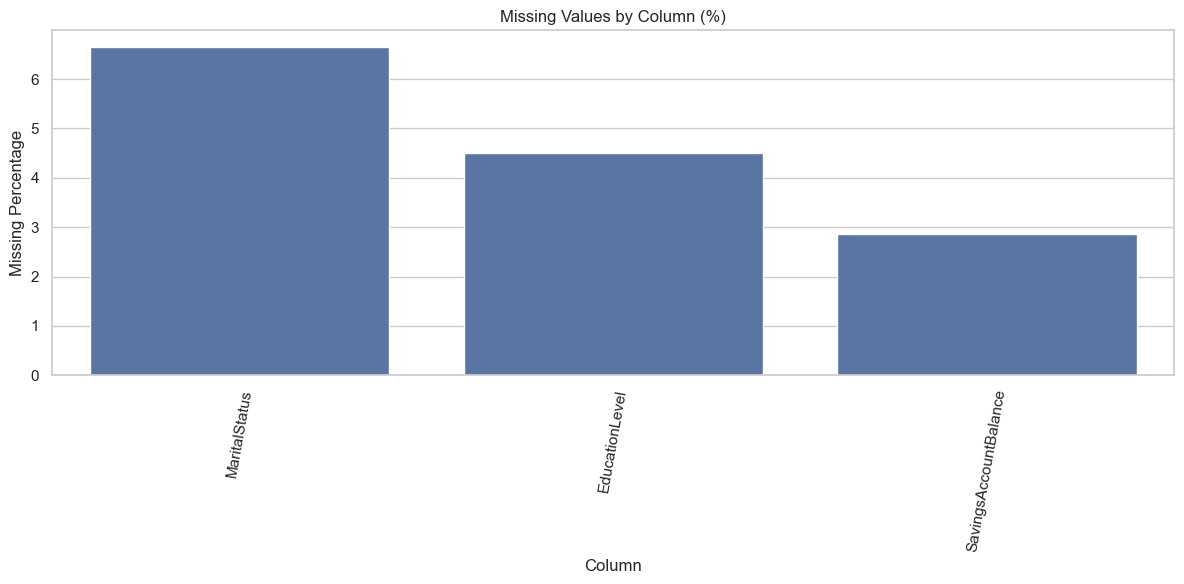

In [5]:
missing_summary = (
    loan_df.isna().sum().to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(loan_df) * 100)
    .sort_values("missing_percent", ascending=False)
)
display(missing_summary[missing_summary["missing_count"] > 0])

plt.figure(figsize=(12, 6))
missing_plot = missing_summary[missing_summary["missing_count"] > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot["missing_percent"])
    plt.xticks(rotation=80)
    plt.title("Missing Values by Column (%)")
    plt.ylabel("Missing Percentage")
    plt.xlabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

## Results Interpretation: Missing Value Analysis

The analysis identified missing values in only three variables, indicating that the dataset is generally complete and suitable for machine learning after appropriate imputation.

### Summary of Missing Values

| Variable | Missing Values | Missing Percentage |
|----------|---------------:|-------------------:|
| MaritalStatus | 1,331 | 6.655% |
| EducationLevel | 901 | 4.505% |
| SavingsAccountBalance | 572 | 2.860% |

No other variables were found to contain missing values.

### Interpretation of Individual Variables

#### MaritalStatus

MaritalStatus has the highest proportion of missing values, accounting for approximately **6.7%** of all records.

Possible explanations include:

- Applicants choosing not to disclose marital information.
- Incomplete application forms.
- Missing data during capture or transfer processes.

Although marital status may contribute useful contextual information, the missing percentage remains relatively low and does not justify removal of the variable.

#### EducationLevel

EducationLevel contains **4.5%** missing values.

This missingness may arise from:

- Optional disclosure during the application process.
- Historical records lacking educational information.
- Data extraction limitations.

Education can potentially contribute information regarding employment stability and earning potential, making the variable worth retaining.

#### SavingsAccountBalance

SavingsAccountBalance contains the lowest level of missing values at approximately **2.9%**.

Missing savings balances may indicate:

- Inactive savings accounts.
- Unavailable account information.
- Customers without linked savings products.

Because this is a financial variable that may be associated with borrower liquidity and financial resilience, it should be retained and imputed appropriately.

### Graph Interpretation

The missing value bar chart provides a visual comparison of missing values across the affected variables.

Key observations include:

- MaritalStatus exhibits the highest missing percentage.
- EducationLevel has moderate missing values.
- SavingsAccountBalance has relatively limited missing values.
- No variable exceeds 10% missing data.

The visualization confirms that missing values are concentrated within a small number of variables rather than being a widespread data quality issue.

### Implications for Data Preparation

The missing-value pattern is relatively mild and does not require dropping rows or columns.

The recommended imputation strategies (methods used to replace missing data in a dataset with estimated or plausible values) are:

#### Categorical Variables

For:

- MaritalStatus
- EducationLevel

Use:

```python
SimpleImputer(strategy="most_frequent")
```

Reason:

- Preserves all observations.
- Maintains dataset size.
- Suitable for low-to-moderate categorical missingness.

#### Numerical Variable

For:

- SavingsAccountBalance

Use:

```python
SimpleImputer(strategy="median")
```

Reason:

- Financial variables frequently contain outliers.
- Median imputation is more robust than mean imputation.
- Preserves the underlying distribution more effectively.

### Business Implications

From a lending perspective, missing information can influence risk assessment.

- Missing marital information may limit understanding of household financial circumstances.
- Missing education information may reduce visibility into socioeconomic factors associated with financial stability.
- Missing savings balances may obscure a borrower's liquidity position and ability to absorb financial shocks.

However, the overall level of missing values is relatively low and is unlikely to materially affect the model performance once imputation is applied.

### Data Quality Assessment

The overall quality of the dataset remains strong because:

✅ Only three variables contain missing values.

✅ The highest missing percentage is below 7%.

✅ No variable exhibits excessive missing values.

✅ All variables can be retained.

✅ Standard imputation techniques are sufficient to address the issue.


## Target Distribution

The target variable is `LoanApproved`. It is important to check whether the classes are balanced because class imbalance can make accuracy misleading.

,count,percent
LoanApproved,,
0,15220,76.1
1,4780,23.9


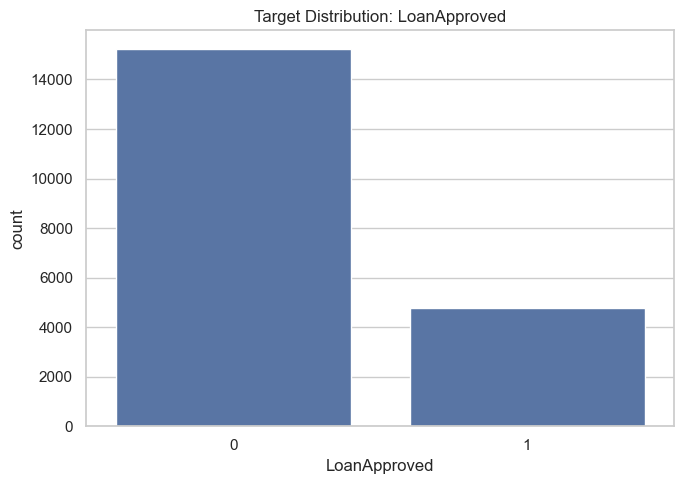

In [6]:
target_distribution = pd.DataFrame({
    "count": loan_df[target_col].value_counts(dropna=False).sort_index(),
    "percent": (loan_df[target_col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
})
display(target_distribution)

plt.figure(figsize=(7,5))
sns.countplot(data=loan_df, x=target_col)
plt.title("Target Distribution: LoanApproved")
plt.tight_layout()
plt.show()

## Results Interpretation: Target Variable Distribution

Before building predictive models, it is essential to understand the distribution of the target variable. The target variable in this study is **LoanApproved**, where:

- **0 = Loan Not Approved**
- **1 = Loan Approved**

The objective of this analysis is to determine whether the classes are balanced, as class imbalance can significantly affect model performance and evaluation.

### Target Distribution Summary

| LoanApproved | Count | Percentage |
|-------------|-------:|-----------:|
| 0 (Not Approved) | 15,220 | 76.1% |
| 1 (Approved) | 4,780 | 23.9% |

The results indicate that the majority of applications were not approved.

### Interpretation of Results

The distribution is clearly imbalanced:

- Approximately **three out of every four applications** were not approved.
- Less than one-quarter of applicants were approved.

This means the target variable does not have an equal representation of both classes.

The approval-to-rejection ratio is approximately:

```text
1 : 3.18
```

meaning there are over three times as many rejected applications as approved applications.

### Graph Interpretation

The bar chart visually confirms the imbalance between the two classes.

Key observations:

- The bar representing **LoanApproved = 0** is substantially taller than the bar representing **LoanApproved = 1**.
- The difference is large enough to classify the dataset as moderately imbalanced.
- Although both classes contain a sufficient number of observations, the imbalance must still be considered during model development.

### Modelling Implications

Class imbalance can create misleading model performance.

For example:

A model that predicts:

```text
Every application = Not Approved
```

would achieve approximately:

```text
76.1% accuracy
```

without learning any meaningful relationships from the data.

This demonstrates why accuracy alone is not an appropriate evaluation metric for this dataset.

Instead, additional metrics are required, including:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Business Cost Metric

These metrics provide a more balanced understanding of performance across both classes.

### Impact on Model Selection

Because the target classes are imbalanced, some models may naturally favour the majority class.

To mitigate this risk, the modeling phase should include:

```python
class_weight="balanced"
```

where supported.

Examples include:

- Logistic Regression
- Decision Tree
- Random Forest

This ensures that the minority class receives appropriate consideration during training.

### Business Implications

The target distribution provides important insight into the organisation's lending process.

The relatively low approval rate suggests that:

- Lending criteria may be strict.
- The dataset contains a significant proportion of high-risk applicants.
- Risk management practices prioritise minimizing potential defaults.

From a business perspective:

#### False Approvals

Approving a high-risk borrower could lead to:

- Loan default
- Financial losses
- Increased provisioning requirements

#### False Rejections

Denying a creditworthy borrower could result in:

- Lost revenue
- Reduced customer satisfaction
- Missed lending opportunities

From the assignment costs per approval outcome:

```text
False Approval Cost = $50,000
False Rejection Cost = $8,000
```

the model should prioritize reducing costly false approvals while still maintaining acceptable approval rates.

### Relationship to Evaluation Metrics

This class imbalance further justifies the selection of:

#### ROC-AUC

ROC-AUC evaluates the model's ability to distinguish between approved and non-approved applicants across multiple thresholds.

#### Precision

Precision helps determine how many approved predictions are actually correct.

#### Recall

Recall measures how effectively the model identifies truly approved applicants.

#### Business Cost Metric

The custom business cost metric aligns model evaluation with real-world financial consequences rather than purely statistical performance.

### Conclusion

The target variable exhibits a moderate class imbalance, with **76.1% of observations representing non-approved loans** and **23.9% representing approved loans**. This imbalance is significant enough to influence model training and evaluation. Further, the model performance should be assessed using multiple metrics beyond accuracy, and class-balancing strategies should be considered during model development.

## Feature Type Categorisation

The dataset contains numeric, categorical, and binary variables. Different feature types need different preprocessing.

In [7]:
feature_df = loan_df.drop(columns=[target_col])
numeric_features_eda = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_eda = feature_df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features ({len(numeric_features_eda)}):")
print(numeric_features_eda)
print(f"\nCategorical features ({len(categorical_features_eda)}):")
print(categorical_features_eda)

Numeric features (29):
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical features (5):
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


## Results Interpretation: Feature Type Categorisation

Feature categorisation was performed to identify the data types present in the dataset and determine the most appropriate preprocessing techniques for each group of variables. This step is critical because different data types require different preparation methods before they can be used in machine learning models.

The analysis identified:

- **29 Numerical Features**
- **5 Categorical Features**

This confirms that the dataset contains a mixture of financial, demographic, behavioural, and loan-related information that will require tailored preprocessing workflows.

### Numerical Features

The dataset contains 29 numerical variables, including:

- Age
- AnnualIncome
- CreditScore
- Experience
- LoanAmount
- LoanDuration
- DebtToIncomeRatio
- CreditCardUtilizationRate
- PaymentHistory
- SavingsAccountBalance
- TotalAssets
- TotalLiabilities
- NetWorth
- MonthlyIncome
- BaseInterestRate
- InterestRate
- RiskScore

These variables represent measurable borrower characteristics and financial risk indicators.

### Interpretation

Numerical features are particularly valuable because they allow:

- Statistical analysis
- Correlation analysis
- Outlier detection
- Feature engineering
- Advanced machine learning modelling

Many of these variables are directly linked to creditworthiness and repayment ability.

For example:

#### CreditScore

Represents historical borrowing behaviour and repayment reliability.

#### DebtToIncomeRatio

Measures affordability and repayment capacity.

#### NetWorth

Reflects overall financial strength and resilience.

#### RiskScore

Provides a summary indication of borrower risk and is likely to be one of the strongest predictors of approval outcomes.

### Categorical Features

The dataset contains five categorical variables:

- EmploymentStatus
- EducationLevel
- MaritalStatus
- HomeOwnershipStatus
- LoanPurpose

These variables describe applicant characteristics rather than numerical measurements.

### Interpretation

Categorical variables often contain valuable contextual information that may influence lending decisions.

Examples include:

#### EmploymentStatus

Can indicate income stability and long-term repayment capacity.

#### HomeOwnershipStatus

May reflect financial strength and accumulated assets.

#### LoanPurpose

Can help distinguish between different lending risks associated with various forms of borrowing.

#### EducationLevel

May indirectly capture socioeconomic and earning-capacity characteristics.

### Why Categorisation Matters

Machine learning algorithms process different data types differently.

#### Numerical Features

Will undergo:

```python
Median Imputation
StandardScaler
```

where appropriate.

The median is used because financial variables often contain outliers.

Scaling is particularly important for algorithms such as:

- Logistic Regression
- Support Vector Machines

because these algorithms are sensitive to differences in variable scale.

#### Categorical Features

Will undergo:

```python
Most Frequent Imputation
OneHotEncoder
```

because machine learning algorithms cannot directly interpret text values such as:

```text
Employed
Married
Mortgage
Education
```

One-hot encoding converts categories into machine-readable binary indicators.

### Business Interpretation

The feature composition of the dataset reflects many of the variables commonly used in real-world credit-risk assessment.

The presence of variables related to:

- Credit history
- Debt burden
- Income
- Assets
- Employment
- Borrowing behaviour

suggests that the model will be able to evaluate multiple dimensions of borrower risk rather than relying on a single metric.

This improves:

- Predictive accuracy
- Explainability
- Risk segmentation
- Lending decision quality

### Feature Engineering Opportunities

This classification also highlights opportunities to create additional predictive variables.

Potential engineered features include:

#### Loan-to-Income Ratio

```text
LoanAmount ÷ AnnualIncome
```

Measures borrowing relative to income.

#### Asset-to-Liability Ratio

```text
TotalAssets ÷ TotalLiabilities
```

Measures financial resilience.

#### Debt Burden Indicator

Derived from DebtToIncomeRatio and MonthlyDebtPayments.

#### Credit Profile Score

Combining:

- CreditScore
- PaymentHistory
- PreviousLoanDefaults
- BankruptcyHistory

into a composite risk indicator.

These engineered variables may capture borrower risk more effectively than individual variables alone.

### Modelling Implications

The mixture of 29 numerical features and 5 categorical features supports the use of a preprocessing framework based on:

```python
ColumnTransformer
```

This approach allows:

- Numerical features to be scaled and imputed.
- Categorical features to be encoded and imputed.
- Consistent preprocessing across training and testing datasets.

The use of a pipeline also reduces the risk of data leakage and improves reproducibility.

## Univariate EDA

The following charts inspect distributions of key financial and credit-risk variables. This helps detect skewness, outliers, and modelling considerations.

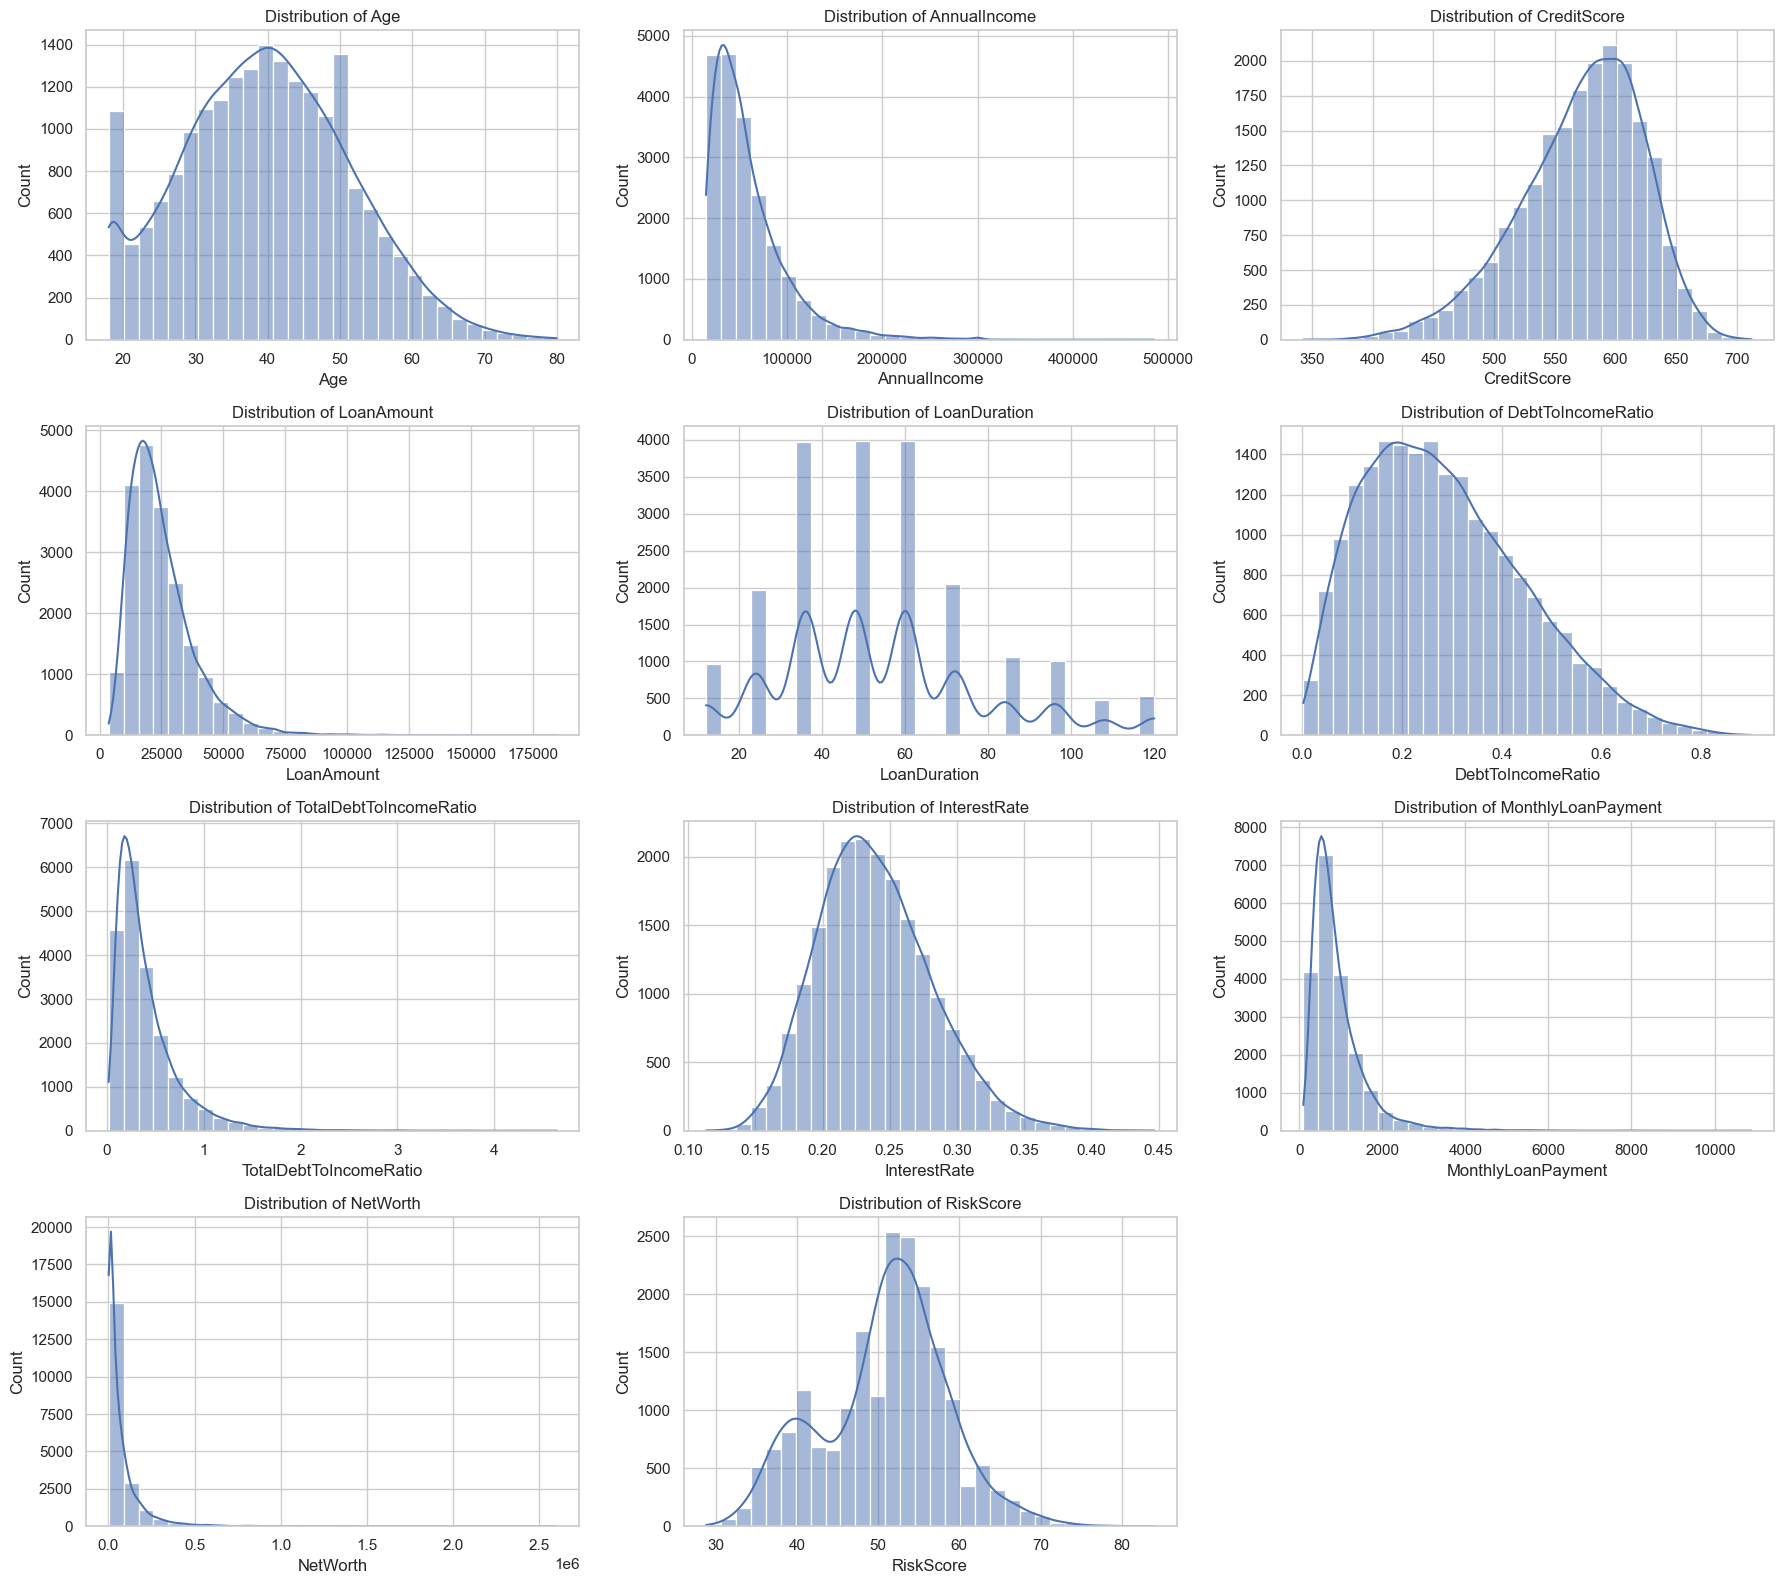

In [8]:
important_numeric = [
    "Age", "AnnualIncome", "CreditScore", "LoanAmount", "LoanDuration",
    "DebtToIncomeRatio", "TotalDebtToIncomeRatio", "InterestRate",
    "MonthlyLoanPayment", "NetWorth", "RiskScore"
]
important_numeric = [c for c in important_numeric if c in loan_df.columns]

n_cols = 3
n_rows = int(np.ceil(len(important_numeric) / n_cols))
plt.figure(figsize=(18, max(5, 4*n_rows)))
for i, col in enumerate(important_numeric, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(loan_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#### Univariate Exploratory Data Analysis (EDA) is the simplest form of Exploratory Data Analysis where you examine only one variable (or column) in a dataset at a time.

## Results Interpretation: Univariate Exploratory Data Analysis (EDA)

Univariate analysis was conducted to understand the distribution of key financial and credit-risk variables individually. Examining each variable in isolation helps identify:

- Central tendencies
- Distribution shapes
- Potential skewness
- Outliers
- Data quality concerns
- Transformation requirements

These insights are important because variable distributions can significantly influence model performance and preprocessing decisions.

## Distribution of Age

The age distribution appears approximately bell-shaped with a concentration between 30 and 50 years.

Meaning:
- Most applicants belong to the economically active population.
- Very young and older applicants form a relatively small proportion of the dataset.
- No significant abnormal spikes or gaps are evident.

Age may capture differences in employment stability, income growth, and financial responsibility. However, age should be used cautiously because of fairness and regulatory considerations.

## Distribution of Annual Income

AnnualIncome exhibits a strong positive (right) skew.

Most applicants earn relatively moderate incomes, while a small number report exceptionally high income levels.

Meaning
- The distribution is not normal.
- Several high-income outliers are visible.
- Average income may be heavily influenced by these extreme values.

Because of the skewness:
- Median statistics are more useful than means.
- Outlier-sensitive algorithms may be affected.
- Log transformations could be considered in future model improvements.

Income is expected to be a strong predictor of repayment ability because higher-income applicants generally possess greater financial capacity to service debt.

## Distribution of Credit Score

CreditScore displays an approximately normal distribution centred around the mid-range credit score values.

Meaning:
- Borrowers exhibit a wide range of credit quality.
- The dataset contains both low-risk and higher-risk applicants.
- No severe skewness is observed.

Credit score is likely to become one of the strongest predictors of loan approval because it directly represents historical credit behaviour and repayment reliability.

## Distribution of Loan Amount

LoanAmount is positively skewed.

Most loans are relatively small to medium-sized, while a smaller number of applications involve substantially larger loan values.

Meaning:
- High-value loan requests are less common.
- A small number of extreme loan amounts influence the upper tail of the distribution.

Large loan requests typically carry greater credit exposure and may require stricter risk assessment and underwriting controls.

## Distribution of Loan Duration

LoanDuration appears concentrated around common lending periods such as:

- 36 months
- 48 months
- 60 months

Meaning:
The distribution reflects structured lending products with predefined repayment periods rather than a fully continuous variable.

Longer loan durations often reduce monthly repayments but increase overall exposure to borrower default risk.

## Distribution of Debt-to-Income Ratio

DebtToIncomeRatio exhibits moderate positive skewness.

Most borrowers have relatively manageable debt burdens, while fewer applicants exhibit high debt obligations.

Meaning:
Higher debt-to-income levels may indicate reduced affordability.

Debt-to-income ratio is widely used in credit-risk assessment because it measures how much of an applicant's income is already committed to debt repayment.

Applicants with higher ratios may represent elevated lending risk.

## Distribution of Total Debt-to-Income Ratio

TotalDebtToIncomeRatio displays substantial positive skewness.

Most borrowers fall within lower ratio levels, while a small number exhibit extremely high leverage.

Meaning:
Several potential high-risk borrowers are visible.

This variable may be a powerful indicator of financial stress and over-indebtedness, making it highly relevant for approval decisions.

## Distribution of Interest Rate

InterestRate appears approximately normally distributed with a concentration around the average lending rate.

Meaning:
The dataset reflects fairly consistent pricing policies, with moderate variation across borrowers.

Higher interest rates may indirectly signal higher borrower risk, as lenders often price risk into lending products.

## Distribution of Monthly Loan Payment

MonthlyLoanPayment is highly right-skewed.

Most borrowers have relatively low-to-moderate monthly obligations, while a smaller group faces substantially larger repayments.

Meaning:
The distribution mirrors the skewness seen in loan amounts.

Large monthly repayments may increase the probability of repayment difficulties, particularly for borrowers with lower disposable income.

## Distribution of Net Worth

NetWorth exhibits extreme positive skewness.

A large number of applicants possess relatively modest net worth, while a small number have exceptionally high asset holdings.

Meaning:
Significant wealth disparities exist among applicants.

The presence of extreme outliers supports the decision to use:

```python
Median Imputation
```

rather than mean-based methods when handling numerical variables.

Net worth provides a useful indication of financial resilience and may help distinguish lower-risk borrowers from individuals with limited financial buffers.

## Distribution of Risk Score

RiskScore appears approximately normally distributed with a concentration around the middle range.

Meaning:
The dataset contains a broad spectrum of applicant risk levels rather than being dominated by only low-risk or high-risk borrowers.

RiskScore is expected to have a strong relationship with loan approval outcomes because it summarises multiple dimensions of borrower risk.



## Overall Findings

Several common patterns emerge across the numerical variables:

### Approximately Normal Distributions

- CreditScore
- InterestRate
- RiskScore
- Age

These variables are already suitable for modelling without major transformation.

### Positively Skewed Variables

- AnnualIncome
- LoanAmount
- MonthlyLoanPayment
- TotalDebtToIncomeRatio
- NetWorth

These variables contain extreme high-value observations and may require careful handling during modelling.

### Evidence of Potential Outliers

Strong skewness suggests the presence of significant outliers, particularly in:

- AnnualIncome
- LoanAmount
- NetWorth
- MonthlyLoanPayment


## Business Interpretation

The dataset reflects realistic lending behaviour:

- Most borrowers have moderate financial profiles.
- A smaller number represent higher-income, higher-wealth, or higher-loan-value customers.
- Debt affordability measures vary significantly between applicants.
- Creditworthiness varies across a broad range of risk levels.

These findings support the use of machine learning because meaningful variation exists across the applicant population, allowing predictive models to learn patterns associated with loan approval decisions.


The univariate analysis confirms that the dataset contains realistic credit-risk and financial behaviour patterns. Most variables exhibit logical distributions, although several financial measures show positive skewness and potential outliers. These findings justify the use of robust preprocessing techniques and provide confidence that the dataset contains informative predictors for loan approval modelling.

## Categorical EDA

These charts compare approval distribution across employment, education, marital status, home ownership, and loan purpose.

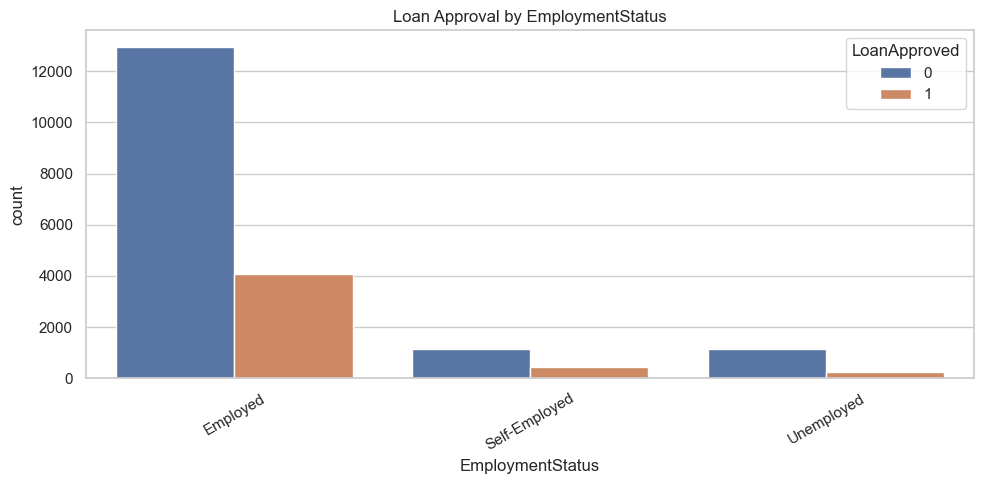

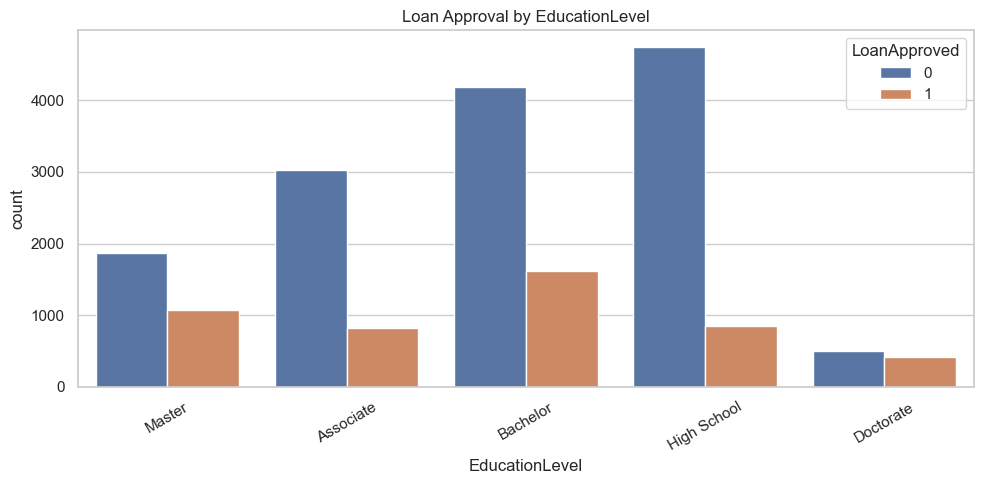

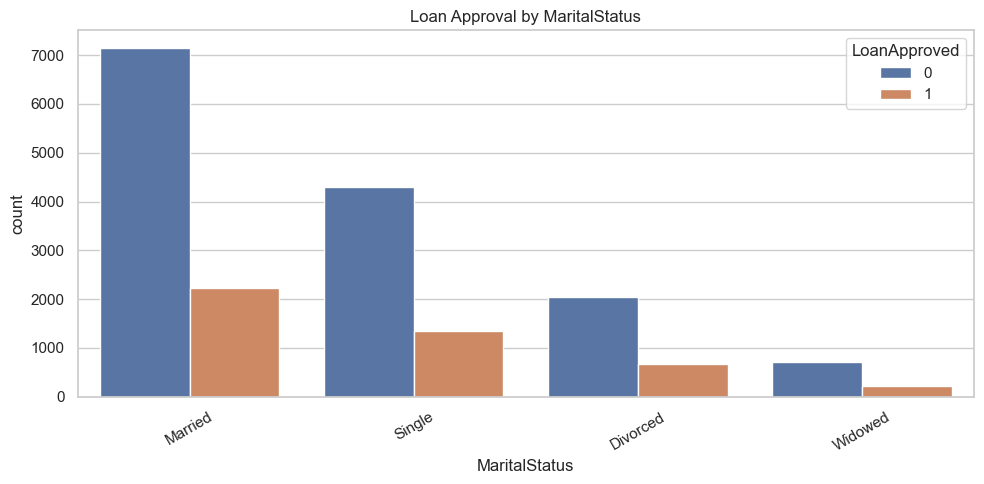

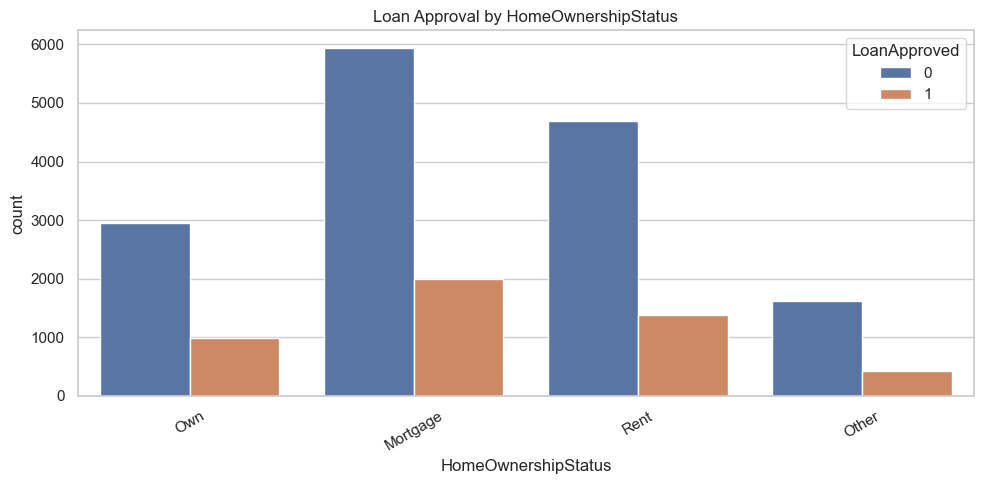

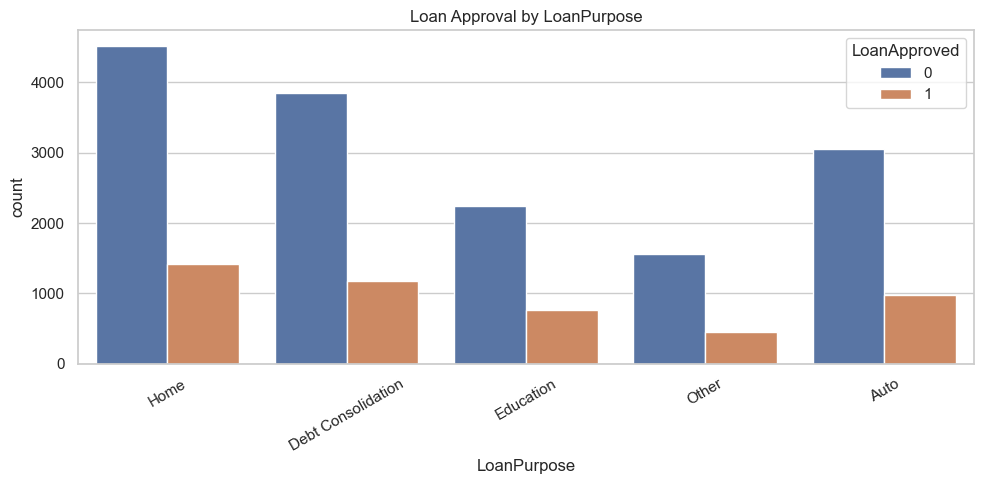

In [9]:
important_categorical = ["EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", "LoanPurpose"]
important_categorical = [c for c in important_categorical if c in loan_df.columns]

for col in important_categorical:
    plt.figure(figsize=(10,5))
    sns.countplot(data=loan_df, x=col, hue=target_col)
    plt.title(f"Loan Approval by {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Results Interpretation: Categorical Exploratory Data Analysis

Categorical exploratory data analysis was performed to investigate how loan approval outcomes vary across important borrower characteristics. Unlike numerical variables, categorical variables help explain how different groups of applicants compare in terms of approval and rejection outcomes.

The analysis focused on five key variables:

- Employment Status
- Education Level
- Marital Status
- Home Ownership Status
- Loan Purpose

The objective was to identify whether certain borrower groups exhibit different approval patterns that could influence predictive modelling.

## Employment Status Analysis

The majority of applicants are employed, and this category also accounts for the largest number of approved loans.

Key observations include:

- Employed applicants dominate the dataset.
- Self-employed applicants represent a smaller proportion of borrowers.
- Unemployed applicants have the lowest number of approvals.

Employment status appears to be associated with approval outcomes.

Applicants with stable employment generally demonstrate:

- Predictable income streams
- Greater repayment capacity
- Lower perceived lending risk

Conversely, unemployed applicants are likely to present higher uncertainty regarding future income and loan repayment.

Employment status is an important underwriting factor because income stability is often linked to repayment ability. The observed patterns suggest that employment status may contribute useful predictive information during model training.

## Education Level Analysis

Approval volumes differ across education groups.

Key patterns include:

- Bachelor's and High School categories contain the largest number of applicants.
- Bachelor's degree holders show a relatively high number of approvals.
- Doctorate holders represent the smallest group.

Educational attainment may be associated with:

- Income potential
- Employment opportunities
- Financial stability

However, differences in approval counts may partly reflect differences in group size rather than approval rates alone.

Education level may provide additional predictive value when combined with:

- Income
- Employment status
- Creditworthiness metrics

However, education should not be used as a standalone approval criterion because it may raise fairness and regulatory considerations.

## Marital Status Analysis

Married applicants represent the largest group and also account for the highest number of approvals.

Other categories include:

- Single
- Divorced
- Widowed

Marital status may indirectly reflect household structure, financial support systems, or shared economic responsibilities.

The higher number of approvals among married borrowers likely reflects:

- Greater representation within the dataset
- Potentially stronger household financial stability

While marital status may contain useful information, lending decisions should not rely heavily on this variable due to potential ethical and regulatory concerns.

Instead, it can serve as a supplementary feature that contributes to broader risk assessment.

## Home Ownership Status Analysis

The largest groups are:

- Mortgage holders
- Renters

Homeowners and the "Other" category form smaller groups.

Mortgage holders also show the highest number of approved loans.

Home ownership often reflects:

- Asset accumulation
- Financial maturity
- Long-term financial stability

Mortgage holders may be perceived as lower-risk borrowers because they have demonstrated the ability to maintain long-term credit obligations.

Home ownership status is frequently used in credit-risk modelling because it provides indirect information regarding:

- Asset ownership
- Financial commitment
- Economic stability

The observed approval patterns suggest it may be an informative feature in the predictive model.

## Loan Purpose Analysis

Loan applications are distributed across several categories:

- Home
- Debt Consolidation
- Education
- Auto
- Other

Home-related loans and debt consolidation loans account for the largest number of applications.

The purpose of borrowing may influence perceived lending risk.

For example:

#### Home Loans

Typically associated with asset acquisition and potentially lower lending risk.

#### Debt Consolidation Loans

May indicate borrowers seeking to restructure existing debt obligations.

#### Education Loans

Can represent long-term investment in income-generating potential.

#### Auto Loans

Associated with vehicle purchases and generally involve clearly defined repayment structures.

Different loan purposes may exhibit different default risk profiles.

Understanding these differences can help:

- Improve underwriting strategies
- Segment customer risk
- Enhance lending policies

## Overall Findings

Several important themes emerge from the categorical analysis:

### Strong Borrower Representation

The dataset is dominated by:

- Employed borrowers
- Married applicants
- Mortgage holders
- Home and Debt Consolidation borrowers

### Potential Predictive Variables

The variables most likely to contribute useful predictive information include:

- EmploymentStatus
- HomeOwnershipStatus
- LoanPurpose

These variables exhibit visible differences in approval distributions across categories.

### Class Distribution Consideration

An important observation across all charts is that:

```text
Rejections (LoanApproved = 0) consistently exceed approvals (LoanApproved = 1)
```

This reinforces the class imbalance identified during the target distribution analysis.


## Modelling Considerations

These categorical variables cannot be used directly by most machine learning algorithms.

Therefore, they require:

```python
OneHotEncoder(handle_unknown="ignore")
```

during preprocessing.

Encoding will transform each category into a machine-readable binary feature while preserving the information contained within the original variables.


The categorical analysis suggests that borrower characteristics such as employment status, housing situation, and loan purpose influence approval outcomes.

These factors complement the financial metrics analysed earlier and provide a broader understanding of applicant risk.

Combining:

- Financial variables
- Credit history variables
- Demographic characteristics

is likely to improve model performance by capturing multiple dimensions of borrower behaviour and risk.

The categorical EDA reveals meaningful differences in approval distributions across employment status, education level, marital status, home ownership status, and loan purpose. The observed patterns suggest that these variables contain useful information for loan approval prediction and justify their inclusion in the modelling process.

## Bivariate Analysis

These boxplots compare key numeric risk variables by approval status. They help show whether approved and non-approved applicants differ financially or behaviourally.

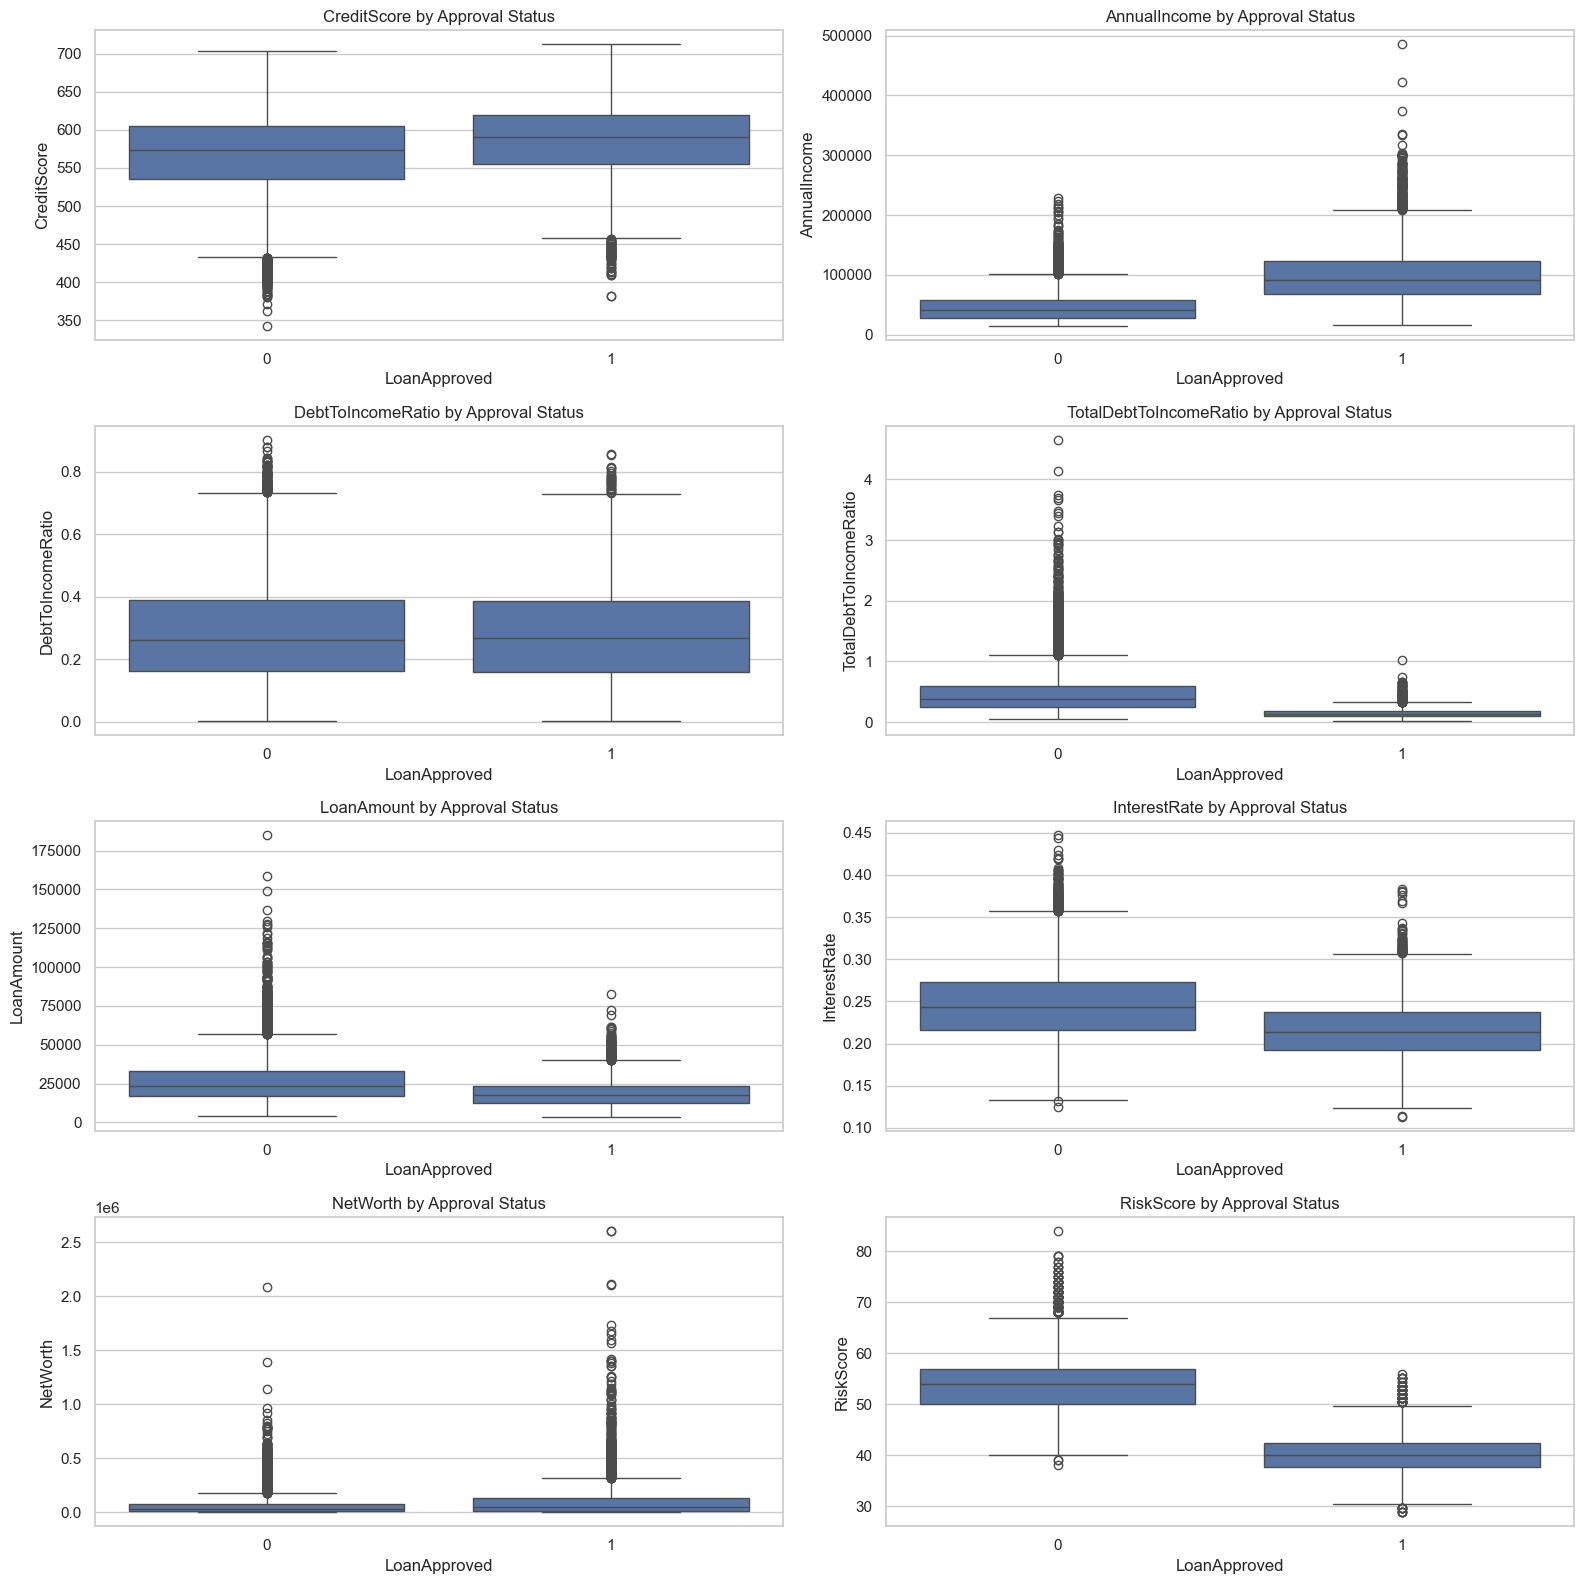

In [10]:
boxplot_features = ["CreditScore", "AnnualIncome", "DebtToIncomeRatio", "TotalDebtToIncomeRatio", "LoanAmount", "InterestRate", "NetWorth", "RiskScore"]
boxplot_features = [c for c in boxplot_features if c in loan_df.columns]

n_cols = 2
n_rows = int(np.ceil(len(boxplot_features) / n_cols))
plt.figure(figsize=(16, max(5, 4*n_rows)))
for i, col in enumerate(boxplot_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=loan_df, x=target_col, y=col)
    plt.title(f"{col} by Approval Status")
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation helps identify relationships among numeric variables and features most associated with the target.

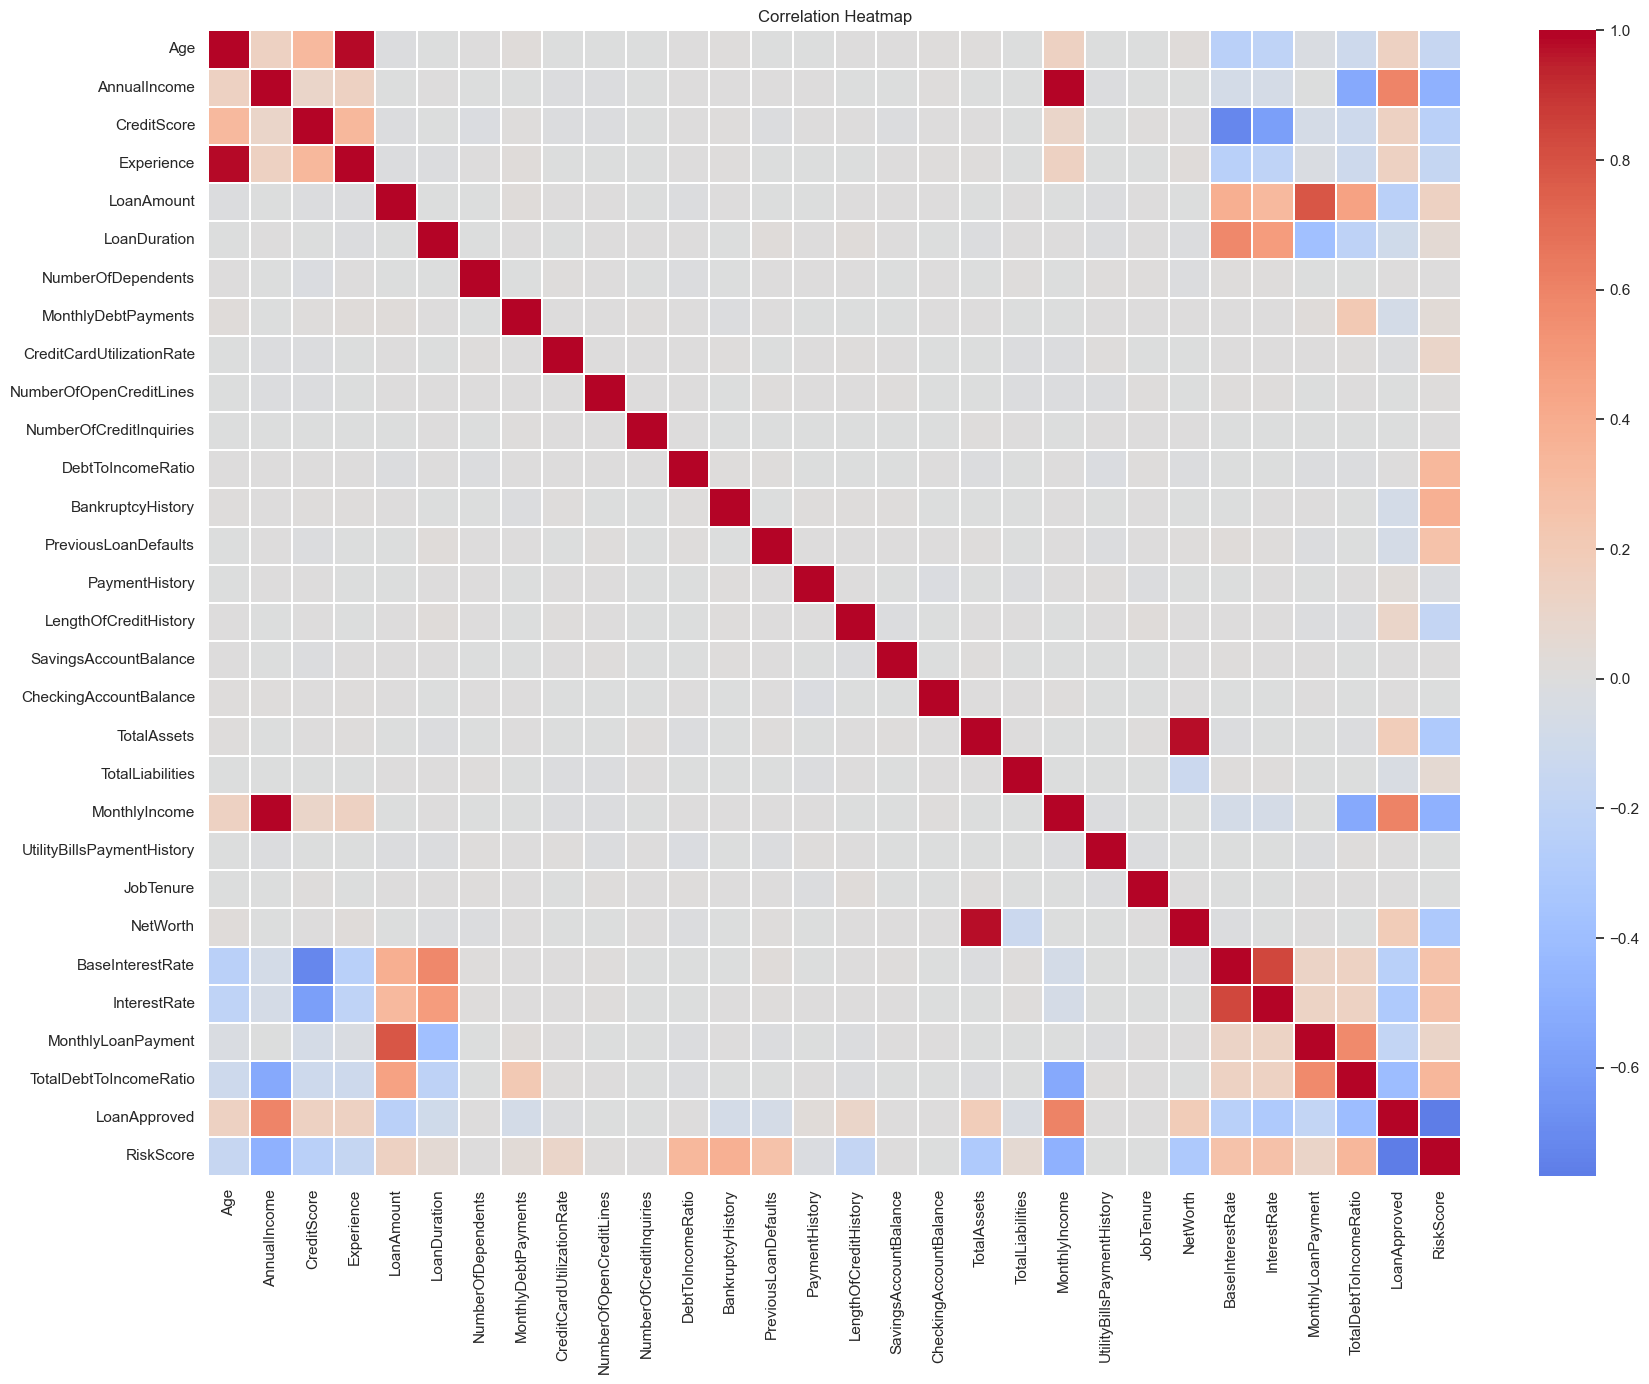

,correlation_with_target
RiskScore,-0.766137
MonthlyIncome,0.604101
AnnualIncome,0.597900
TotalDebtToIncomeRatio,-0.410399
InterestRate,-0.301646
BaseInterestRate,-0.247263
LoanAmount,-0.239496
NetWorth,0.187892
MonthlyLoanPayment,-0.184272
TotalAssets,0.184011


In [11]:
numeric_df = loan_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

if target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=lambda x: x.abs(), ascending=False)
    display(target_corr.head(15).to_frame("correlation_with_target"))

## Results Interpretation: Correlation Analysis

### Overview

Correlation analysis was performed to measure the strength and direction of linear relationships between numerical variables in the dataset. This helps identify which variables are most strongly associated with the target variable, `LoanApproved`, and also highlights possible relationships among predictor variables.

Correlation values range from:

- **+1.0**: perfect positive relationship
- **0.0**: no linear relationship
- **-1.0**: perfect negative relationship

This analysis is useful for understanding potential drivers of loan approval before building machine learning models.

## Correlation Heatmap Interpretation

### What the Heatmap Shows

The heatmap visualizes the pairwise correlations between all numerical variables.

The color scale represents the strength and direction of the relationship:

- Dark red indicates strong positive correlation.
- Dark blue indicates strong negative correlation.
- Light or grey colors indicate weak or near-zero correlation.
- The diagonal values are always 1.0 because each variable is perfectly correlated with itself.

### Key Observations from the Heatmap

Several important relationships are visible:

#### 1. Age and Experience

Age and Experience show a very strong positive relationship.

This is expected because older applicants are generally more likely to have accumulated more years of work experience.

#### 2. AnnualIncome and MonthlyIncome

AnnualIncome and MonthlyIncome are highly positively correlated.

This is expected because MonthlyIncome is derived from AnnualIncome.

#### 3. LoanAmount, MonthlyLoanPayment, and TotalDebtToIncomeRatio

LoanAmount shows a visible relationship with MonthlyLoanPayment and TotalDebtToIncomeRatio.

This makes business sense because larger loan amounts usually result in higher monthly repayments, which then increase total debt burden.

#### 4. InterestRate and BaseInterestRate

InterestRate and BaseInterestRate show a strong positive relationship.

This indicates that the final interest rate is closely linked to the base interest rate calculation.

#### 5. LoanApproved and RiskScore

LoanApproved has a strong negative relationship with RiskScore.

This means that as RiskScore increases, the probability of loan approval decreases.

This is one of the most important findings in the correlation analysis.


## Target Correlation Results

The table showing the top correlations with `LoanApproved` provides the most direct insight into variables associated with approval outcomes.

The strongest correlations with the target are:

| Feature | Correlation with LoanApproved |
|---|---:|
| RiskScore | -0.766137 |
| MonthlyIncome | 0.604101 |
| AnnualIncome | 0.597900 |
| TotalDebtToIncomeRatio | -0.410399 |
| InterestRate | -0.301646 |
| BaseInterestRate | -0.247263 |
| LoanAmount | -0.239496 |
| NetWorth | 0.187892 |
| MonthlyLoanPayment | -0.184272 |
| TotalAssets | 0.184011 |
| CreditScore | 0.142000 |
| Age | 0.141029 |
| Experience | 0.140755 |
| LengthOfCreditHistory | 0.105949 |
| LoanDuration | -0.094558 |


## Interpretation of Key Target Relationships

### RiskScore

RiskScore has the strongest correlation with LoanApproved:

```text
Correlation = -0.766137
```

This is a strong negative correlation.

### Interpretation

As RiskScore increases, the likelihood of loan approval decreases.

This suggests that RiskScore is highly informative and may be one of the strongest predictors in the model.

### Business Implication

The result aligns with credit-risk logic. Applicants with higher risk scores are less likely to be approved because they may represent greater probability of default or repayment difficulty.



## MonthlyIncome and AnnualIncome

MonthlyIncome and AnnualIncome show strong positive correlations with LoanApproved:

```text
MonthlyIncome correlation = 0.604101
AnnualIncome correlation = 0.597900
```

### Interpretation

Applicants with higher income levels are more likely to be approved.

This suggests that affordability and repayment capacity are central to the approval decision.

### Business Implication

Income is a major indicator of repayment ability. Higher-income applicants are likely viewed as lower-risk because they have greater capacity to meet monthly repayment obligations.


## TotalDebtToIncomeRatio

TotalDebtToIncomeRatio has a negative correlation with LoanApproved:

```text
Correlation = -0.410399
```

### Interpretation

As total debt-to-income ratio increases, the probability of loan approval decreases.

This indicates that highly leveraged borrowers are less likely to be approved.

### Business Implication

This is consistent with lending practice. Borrowers with high debt obligations relative to income have less disposable income available for new loan repayments, increasing default risk.


## InterestRate and BaseInterestRate

InterestRate and BaseInterestRate both show negative relationships with LoanApproved:

```text
InterestRate correlation = -0.301646
BaseInterestRate correlation = -0.247263
```

### Interpretation

Higher interest rates are associated with lower likelihood of approval.

This may indicate that higher-risk applicants are priced at higher rates or that interest rates reflect underlying borrower risk.

### Business Implication

Interest rate may act as both a pricing variable and a risk indicator. Higher rates can increase repayment burden and may be associated with applicants who are already considered riskier.



## LoanAmount

LoanAmount has a negative correlation with LoanApproved:

```text
Correlation = -0.239496
```

### Interpretation

Larger loan requests are associated with lower approval likelihood.

### Business Implication

Higher loan amounts create greater credit exposure for the lender. Unless supported by sufficient income, assets, and repayment history, larger loan requests may be viewed as riskier.



## NetWorth and TotalAssets

NetWorth and TotalAssets have positive relationships with LoanApproved:

```text
NetWorth correlation = 0.187892
TotalAssets correlation = 0.184011
```

### Interpretation

Applicants with stronger asset positions and higher net worth are more likely to be approved.

### Business Implication

This suggests that financial resilience matters in approval decisions. Borrowers with more assets may be better able to absorb financial shocks and continue servicing debt.



## CreditScore

CreditScore has a positive correlation with LoanApproved:

```text
Correlation = 0.142000
```

### Interpretation

Applicants with higher credit scores are more likely to be approved.

Although the correlation is weaker than RiskScore or Income, it still moves in the expected direction.

### Business Implication

CreditScore remains an important indicator of repayment history and creditworthiness. However, the relatively modest correlation suggests that loan approval is influenced by several variables together, not credit score alone.



## Age, Experience, and LengthOfCreditHistory

Age, Experience, and LengthOfCreditHistory all show positive relationships with LoanApproved.

### Interpretation

Applicants with more experience, longer credit histories, and older age profiles tend to have slightly higher approval likelihood.

### Business Implication

These variables may indirectly reflect financial maturity, employment stability, and longer borrowing history. However, they should be used carefully to avoid overreliance on demographic characteristics.



## LoanDuration

LoanDuration shows a weak negative relationship with LoanApproved:

```text
Correlation = -0.094558
```

### Interpretation

Longer loan durations are slightly associated with lower approval likelihood.

### Business Implication

Longer repayment terms may increase exposure to future uncertainty and repayment risk, although the relationship is relatively weak.



## Modelling Implications

The correlation analysis suggests that the most important candidate predictors are likely to include:

1. RiskScore
2. MonthlyIncome
3. AnnualIncome
4. TotalDebtToIncomeRatio
5. InterestRate
6. LoanAmount
7. NetWorth
8. TotalAssets
9. CreditScore

These variables should be retained for model development.

However, correlation only captures linear relationships. Some variables may still be useful even if their linear correlation with the target is weak, especially in tree-based models such as Random Forest and Gradient Boosting.



## Multicollinearity Considerations

Some variables appear strongly related to each other, including:

- AnnualIncome and MonthlyIncome
- Age and Experience
- InterestRate and BaseInterestRate
- LoanAmount and MonthlyLoanPayment

### Implication

Highly correlated predictor variables may introduce redundancy, especially for linear models such as Logistic Regression.

However, tree-based models are generally more tolerant of correlated features. For interpretability, highly related variables should still be reviewed carefully during feature importance analysis.



## Business Interpretation

The results align strongly with lending logic.

Applicants are more likely to be approved when they have:

- Lower RiskScore
- Higher income
- Lower total debt burden
- Lower interest rates
- Stronger net worth
- Higher assets
- Stronger credit profiles

Applicants are less likely to be approved when they have:

- Higher risk scores
- Higher debt-to-income ratios
- Higher requested loan amounts
- Higher interest rates
- Higher monthly repayment burdens

This provides confidence that the dataset contains meaningful and realistic credit-risk relationships.

The correlation analysis confirms that loan approval is strongly associated with borrower risk, income, affordability, and financial strength. RiskScore has the strongest negative correlation with approval, while income variables have the strongest positive correlations. These findings support the modelling approach.

## Outlier Review

Financial datasets commonly contain legitimate outliers such as high-income borrowers or large asset balances. These values are not automatically removed. Instead, robust preprocessing and tree-based models are used.

In [12]:
outlier_features = ["AnnualIncome", "LoanAmount", "TotalAssets", "TotalLiabilities", "NetWorth", "TotalDebtToIncomeRatio"]
outlier_features = [c for c in outlier_features if c in loan_df.columns]

outlier_rows = []
for col in outlier_features:
    q1, q3 = loan_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((loan_df[col] < lower) | (loan_df[col] > upper)).sum()
    outlier_rows.append([col, lower, upper, count, round(count/len(loan_df)*100,2)])

outlier_report = pd.DataFrame(outlier_rows, columns=["feature", "lower_bound", "upper_bound", "outlier_count", "outlier_percent"] )
display(outlier_report)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,AnnualIncome,-32389.000000,138459.000000,947,4.74
1,LoanAmount,-7315.000000,53725.000000,746,3.73
2,TotalAssets,-98157.250000,246742.750000,1442,7.21
3,TotalLiabilities,-36727.875000,91071.125000,1533,7.66
4,NetWorth,-111401.375000,208961.625000,1564,7.82
5,TotalDebtToIncomeRatio,-0.314588,1.003494,1152,5.76


## Results Interpretation: Outlier Review

Outlier analysis was conducted to identify observations that fall significantly outside the typical range of values for key financial variables. The Interquartile Range (IQR) method was used, where observations falling below:

```text
Q1 − 1.5 × IQR
```

or above:

```text
Q3 + 1.5 × IQR
```

were classified as outliers.

Outliers are common in financial datasets because some applicants naturally possess substantially higher incomes, asset values, liabilities, or borrowing exposures than the majority of borrowers.

The purpose of this analysis is not necessarily to remove outliers, but to understand their extent and assess their impact on modelling.

## Summary of Outliers Identified

| Feature | Outlier Count | Outlier Percentage |
|----------|--------------:|------------------:|
| NetWorth | 1,564 | 7.82% |
| TotalLiabilities | 1,533 | 7.66% |
| TotalAssets | 1,442 | 7.21% |
| TotalDebtToIncomeRatio | 1,152 | 5.76% |
| AnnualIncome | 947 | 4.74% |
| LoanAmount | 746 | 3.73% |

The results indicate that outliers are present across all major financial variables, with the highest proportion occurring in NetWorth.

## Annual Income

AnnualIncome contains:

- 947 outliers
- 4.74% of all observations

A small subset of borrowers earn substantially more than the typical applicant.

This is expected in real lending portfolios where:

- Senior executives
- Business owners
- High-net-worth individuals

often coexist with average-income borrowers.

These high-income observations are not necessarily errors and may represent some of the most financially stable borrowers in the dataset.

## Loan Amount

LoanAmount contains:

- 746 outliers
- 3.73% of observations

Some applicants request significantly larger loans than the majority of borrowers.

Large loans create greater credit exposure for the lender and therefore require more careful risk assessment.

The presence of these observations is consistent with genuine lending behaviour and should not automatically be removed.

## Total Assets

TotalAssets contains:

- 1,442 outliers
- 7.21% of observations

A relatively small group of applicants possesses significantly larger asset portfolios than most borrowers.

These borrowers may have stronger financial resilience and may therefore represent lower lending risk despite appearing as statistical outliers.

## Total Liabilities

TotalLiabilities contains:

- 1,533 outliers
- 7.66% of observations

Some applicants carry substantially larger debt obligations than the average borrower.

High liabilities may indicate elevated financial leverage and potential repayment risk.

However, large liabilities do not necessarily imply poor creditworthiness if supported by strong income or asset positions.

## Net Worth

NetWorth exhibits the largest number of outliers:

- 1,564 observations
- 7.82% of the dataset

The distribution of wealth is highly skewed.

A small subset of applicants possesses substantially higher net worth than the majority of borrowers.

High-net-worth borrowers are common in real-world financial datasets.

Because net worth reflects overall financial strength and resilience, these outliers may actually represent some of the most desirable lending candidates.

## Total Debt-to-Income Ratio

TotalDebtToIncomeRatio contains:

- 1,152 outliers
- 5.76% of observations

A notable portion of borrowers have exceptionally high debt burdens relative to income.

Borrowers with extremely high debt-to-income ratios may be more vulnerable to repayment difficulties and therefore represent increased credit risk.

This variable may be particularly useful in distinguishing between approved and non-approved applicants.

## Overall Findings

Several important observations emerge from the analysis:

### Largest Outlier Concentrations

The greatest outlier prevalence occurs in:

1. NetWorth (7.82%)
2. TotalLiabilities (7.66%)
3. TotalAssets (7.21%)

These variables are strongly influenced by financial inequality across borrowers.

### Financial Variables Are Naturally Skewed

Most detected outliers occur within:

- Income
- Assets
- Liabilities
- Net Worth

This behaviour is expected because financial data rarely follows a perfectly normal distribution.

### Outliers Appear to Be Legitimate

There is no evidence suggesting that the detected outliers are data-entry errors.

Instead, they appear to represent:

- High-income borrowers
- High-wealth borrowers
- Borrowers with substantial liabilities
- Large loan applications

These are realistic profiles that should remain available to the model.

## Modelling Implications

Removing all outliers could eliminate important business information.

Therefore:

### Outliers Will Be Retained

The detected outliers are likely genuine borrower characteristics rather than errors.

Removing them would reduce the model's ability to learn from high-value customer segments.

### Robust Preprocessing Is Preferred

To minimize the influence of extreme observations:

```python
SimpleImputer(strategy="median")
```

is preferred over mean-based approaches.

The median is less sensitive to skewed distributions and extreme values.

### Tree-Based Models Are Appropriate

Models such as:

- Random Forest
- Gradient Boosting

are generally robust to outliers and can capture complex nonlinear relationships without requiring extensive outlier treatment.

The presence of financial outliers reflects the diversity of the lending portfolio.

The dataset includes:

- Low-income borrowers
- Average-income borrowers
- High-net-worth customers
- Large loan applicants
- Highly leveraged individuals

From a business perspective, these groups are important because they often behave differently in terms of repayment risk and approval outcomes.

A well-performing machine learning model should be capable of learning from these differences rather than simply removing them.

The outlier analysis identified meaningful outliers across several key financial variables, with NetWorth, TotalLiabilities, and TotalAssets exhibiting the highest proportions. These outliers appear to represent legitimate borrower profiles rather than data quality problems. Consequently, they will be retained in the dataset.

# Data Preparation

## 5. Preprocessing Strategy

The preprocessing is implemented inside a scikit-learn `Pipeline` and `ColumnTransformer`. This prevents data leakage because imputation, encoding, and scaling are learned only from training folds during cross-validation.

### Decisions

- Numeric missing values: median imputation because monetary values may contain outliers.
- Categorical missing values: most frequent imputation to retain all records.
- Categorical encoding: one-hot encoding because categories are mostly nominal.
- Scaling: standard scaling to support Logistic Regression.
- Feature engineering: ratios are added to capture affordability and borrower leverage.

In [13]:
model_df = loan_df.copy()

if {"LoanAmount", "AnnualIncome"}.issubset(model_df.columns):
    model_df["LoanToIncomeRatio"] = model_df["LoanAmount"] / model_df["AnnualIncome"].replace(0, np.nan)

if {"TotalAssets", "TotalLiabilities"}.issubset(model_df.columns):
    model_df["AssetToLiabilityRatio"] = model_df["TotalAssets"] / model_df["TotalLiabilities"].replace(0, np.nan)

if {"MonthlyIncome", "MonthlyDebtPayments", "MonthlyLoanPayment"}.issubset(model_df.columns):
    model_df["MonthlyDisposableIncome"] = model_df["MonthlyIncome"] - model_df["MonthlyDebtPayments"] - model_df["MonthlyLoanPayment"]

if "TotalDebtToIncomeRatio" in model_df.columns:
    model_df["HighDTIFlag"] = (model_df["TotalDebtToIncomeRatio"] > 0.5).astype(int)

model_df = model_df.dropna(subset=[target_col]).copy()
model_df[target_col] = model_df[target_col].astype(int)

display(model_df.head())
print("Model dataset shape:", model_df.shape)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,LoanToIncomeRatio,AssetToLiabilityRatio,MonthlyDisposableIncome,HighDTIFlag
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,0.329228,7.616692,2726.194008,0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,0.655897,5.544971,2019.029095,0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,0.432841,0.195354,1825.259979,0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,0.548579,19.519926,3954.493020,0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,0.088937,14.133114,8001.154193,0


Model dataset shape: (20000, 39)


In [14]:
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# Avoid raw date leakage or unsupported date processing in this version
for col in ["ApplicationDate"]:
    if col in X.columns:
        X = X.drop(columns=[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(y_train.value_counts(normalize=True).to_frame("train_target_percent"))
display(y_test.value_counts(normalize=True).to_frame("test_target_percent"))

Train shape: (16000, 38)
Test shape: (4000, 38)


,train_target_percent
LoanApproved,
0,0.761
1,0.239


,test_target_percent
LoanApproved,
0,0.761
1,0.239


In [15]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore', 'LoanToIncomeRatio', 'AssetToLiabilityRatio', 'MonthlyDisposableIncome', 'HighDTIFlag']
Categorical features: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


# Modeling

## 6. Model Selection and Validation Strategy

Five models are compared:

1. Dummy baseline
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. Gradient Boosting

This satisfies the requirement to compare multiple modelling approaches. Cross-validation is used to estimate generalization performance before final test evaluation.

In [16]:
def business_cost(y_true, y_pred, fp_cost=50_000, fn_cost=8_000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * fp_cost) + (fn * fn_cost)

def evaluate_predictions(y_true, y_pred, y_proba=None):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "business_cost": business_cost(y_true, y_pred)
    }
    result["roc_auc"] = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    return result

In [17]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_split=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    cv_scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else None
    test_metrics = evaluate_predictions(y_test, pred, proba)
    results.append({
        "model": name,
        "cv_accuracy": cv_scores["test_accuracy"].mean(),
        "cv_precision": cv_scores["test_precision"].mean(),
        "cv_recall": cv_scores["test_recall"].mean(),
        "cv_f1": cv_scores["test_f1"].mean(),
        "cv_roc_auc": cv_scores["test_roc_auc"].mean(),
        **{f"test_{k}": v for k, v in test_metrics.items()}
    })

model_results = pd.DataFrame(results).sort_values(["test_business_cost", "test_roc_auc"], ascending=[True, False])
display(model_results)

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_business_cost,test_roc_auc
1,Logistic Regression,0.999312,0.997394,0.999739,0.998564,0.999995,0.99925,0.997910,0.998954,0.998432,108000,0.999975
4,Gradient Boosting,0.997812,0.996595,0.994246,0.995418,0.999958,0.99725,0.996845,0.991632,0.994232,214000,0.999946
3,Random Forest,0.988500,0.978712,0.973064,0.975868,0.999184,0.98875,0.977964,0.974895,0.976427,1242000,0.999258
2,Decision Tree,0.987625,0.966325,0.982479,0.974313,0.985722,0.98850,0.965235,0.987448,0.976215,1796000,0.991560
0,Dummy Baseline,0.761000,0.000000,0.000000,0.000000,0.500000,0.76100,0.000000,0.000000,0.000000,7648000,0.500000


## Model Comparison Discussion

Use the model comparison table to choose a model based on both predictive performance and business cost. A model with slightly lower accuracy may still be preferred if it materially reduces false approvals and therefore lowers the dollar-value loss.

## 7. Hyperparameter Tuning

Random Forest is tuned because it usually performs strongly on structured tabular data and provides feature importance. RandomizedSearchCV is used to demonstrate tuning efficiently.

In [18]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best CV ROC-AUC:", rf_search.best_score_)
print("Best parameters:", rf_search.best_params_)
best_model = rf_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC: 0.9994631652848325
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 15}


## Threshold Optimization

The default threshold of 0.50 may not be business-optimal because false approvals and false rejections have different costs. The code below tests thresholds and selects the one with the lowest business cost.

Best threshold: 0.70


,accuracy,precision,recall,f1,business_cost,roc_auc,threshold
60,0.99225,0.991498,0.975941,0.983658,584000,0.998965,0.70
61,0.99225,0.991498,0.975941,0.983658,584000,0.998965,0.71
69,0.98950,0.993521,0.962343,0.977683,588000,0.998965,0.79
70,0.98925,0.993514,0.961297,0.977140,596000,0.998965,0.80
65,0.99025,0.992481,0.966527,0.979332,606000,0.998965,0.75
71,0.98875,0.993499,0.959205,0.976051,612000,0.998965,0.81
66,0.99000,0.992473,0.965481,0.978791,614000,0.998965,0.76
62,0.99125,0.991462,0.971757,0.981511,616000,0.998965,0.72
67,0.98975,0.992465,0.964435,0.978249,622000,0.998965,0.77
68,0.98975,0.992465,0.964435,0.978249,622000,0.998965,0.78


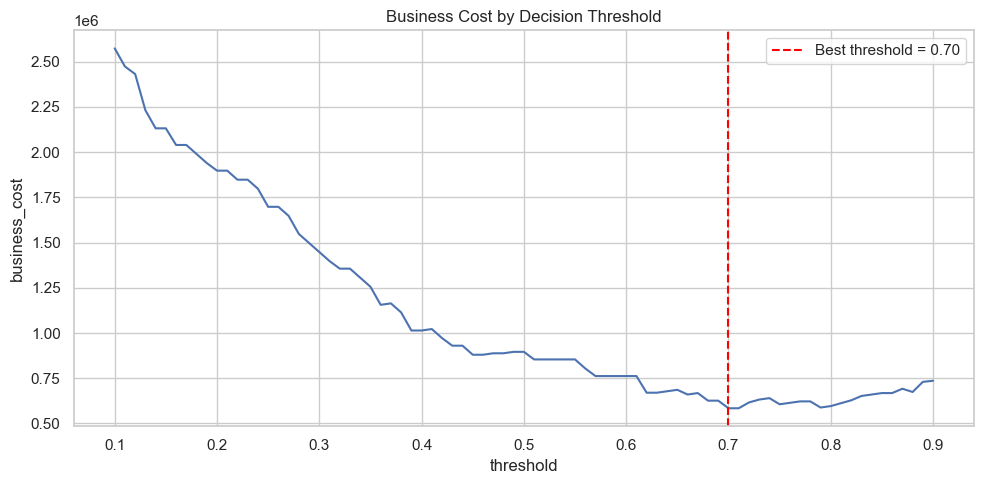

In [19]:
test_proba = best_model.predict_proba(X_test)[:, 1]
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    pred_t = (test_proba >= threshold).astype(int)
    row = evaluate_predictions(y_test, pred_t, test_proba)
    row["threshold"] = threshold
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows).sort_values("business_cost")
best_threshold = float(threshold_results.iloc[0]["threshold"])
print(f"Best threshold: {best_threshold:.2f}")
display(threshold_results.head(10))

plt.figure(figsize=(10,5))
sns.lineplot(data=threshold_results.sort_values("threshold"), x="threshold", y="business_cost")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Business Cost by Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation and Conclusion

## 8. Final Model Evaluation

The final tuned model is assessed on the test set using the threshold that minimizes business cost.

,accuracy,precision,recall,f1,business_cost,roc_auc
Final Tuned Random Forest,0.99225,0.991498,0.975941,0.983658,584000,0.998965


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.99      0.98      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



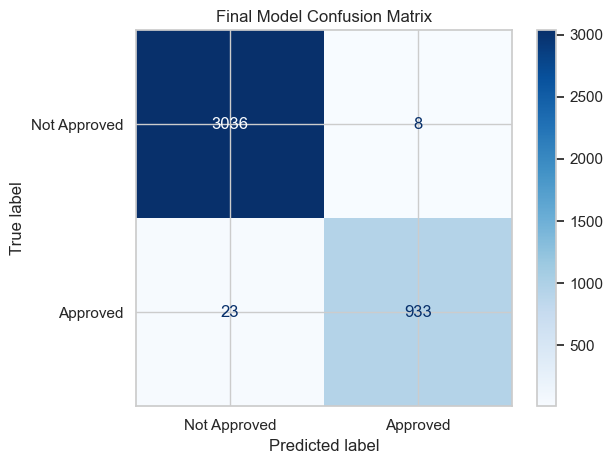

True Negatives: 3036
False Positives: 8
False Negatives: 23
True Positives: 933
Business Cost = $584,000


In [20]:
final_pred = (test_proba >= best_threshold).astype(int)
final_metrics = evaluate_predictions(y_test, final_pred, test_proba)
display(pd.DataFrame(final_metrics, index=["Final Tuned Random Forest"]))

print("Classification Report:")
print(classification_report(y_test, final_pred, zero_division=0))

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Approved", "Approved"]).plot(cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"Business Cost = ${business_cost(y_test, final_pred):,.0f}")

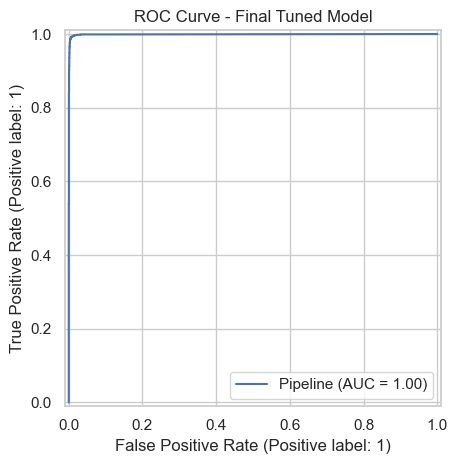

In [21]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Final Tuned Model")
plt.tight_layout()
plt.show()

## Segment-Level Performance

Segment analysis reviews performance across borrower groups such as employment status, education level, home ownership, and loan purpose. This is useful for model risk review and identifying groups that may need closer monitoring.

In [22]:
test_review = X_test.copy()
test_review["actual"] = y_test.values
test_review["predicted"] = final_pred
test_review["approval_probability"] = test_proba

segment_cols = ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus", "LoanPurpose"]
segment_cols = [c for c in segment_cols if c in test_review.columns]

segment_rows = []
for col in segment_cols:
    for value, group in test_review.groupby(col):
        auc = roc_auc_score(group["actual"], group["approval_probability"]) if group["actual"].nunique() > 1 else np.nan
        segment_rows.append({
            "segment_column": col,
            "segment_value": value,
            "rows": len(group),
            "accuracy": accuracy_score(group["actual"], group["predicted"]),
            "precision": precision_score(group["actual"], group["predicted"], zero_division=0),
            "recall": recall_score(group["actual"], group["predicted"], zero_division=0),
            "f1": f1_score(group["actual"], group["predicted"], zero_division=0),
            "roc_auc": auc,
            "business_cost": business_cost(group["actual"], group["predicted"])
        })

segment_report = pd.DataFrame(segment_rows).sort_values(["segment_column", "business_cost"], ascending=[True, False])
display(segment_report)

,segment_column,segment_value,rows,accuracy,precision,recall,f1,roc_auc,business_cost
4,EducationLevel,Bachelor,1163,0.992261,0.993750,0.978462,0.986047,0.997922,156000
7,EducationLevel,Master,620,0.985484,0.991266,0.970085,0.980562,0.999491,156000
3,EducationLevel,Associate,782,0.991049,0.987421,0.969136,0.978193,0.999642,140000
6,EducationLevel,High School,1086,0.996317,0.987952,0.987952,0.987952,0.999437,116000
5,EducationLevel,Doctorate,156,0.987179,1.000000,0.971014,0.985294,1.000000,16000
0,EmploymentStatus,Employed,3402,0.992945,0.990196,0.980583,0.985366,0.999598,528000
1,EmploymentStatus,Self-Employed,311,0.980707,1.000000,0.926829,0.962025,0.992704,48000
2,EmploymentStatus,Unemployed,287,0.996516,1.000000,0.980000,0.989899,1.000000,8000
8,HomeOwnershipStatus,Mortgage,1624,0.991995,0.994949,0.972840,0.983770,0.998331,188000
11,HomeOwnershipStatus,Rent,1175,0.992340,0.992481,0.974170,0.983240,0.999673,156000


## 9. Feature Importance

Feature importance explains which variables contributed most to the Random Forest predictions. It should guide business interpretation, but it should not be interpreted as causality.

,feature,importance
28,RiskScore,0.875988
29,LoanToIncomeRatio,0.052453
11,DebtToIncomeRatio,0.031183
27,TotalDebtToIncomeRatio,0.009422
12,BankruptcyHistory,0.007194
25,InterestRate,0.003601
31,MonthlyDisposableIncome,0.003063
13,PreviousLoanDefaults,0.002896
18,TotalAssets,0.001517
2,CreditScore,0.001454


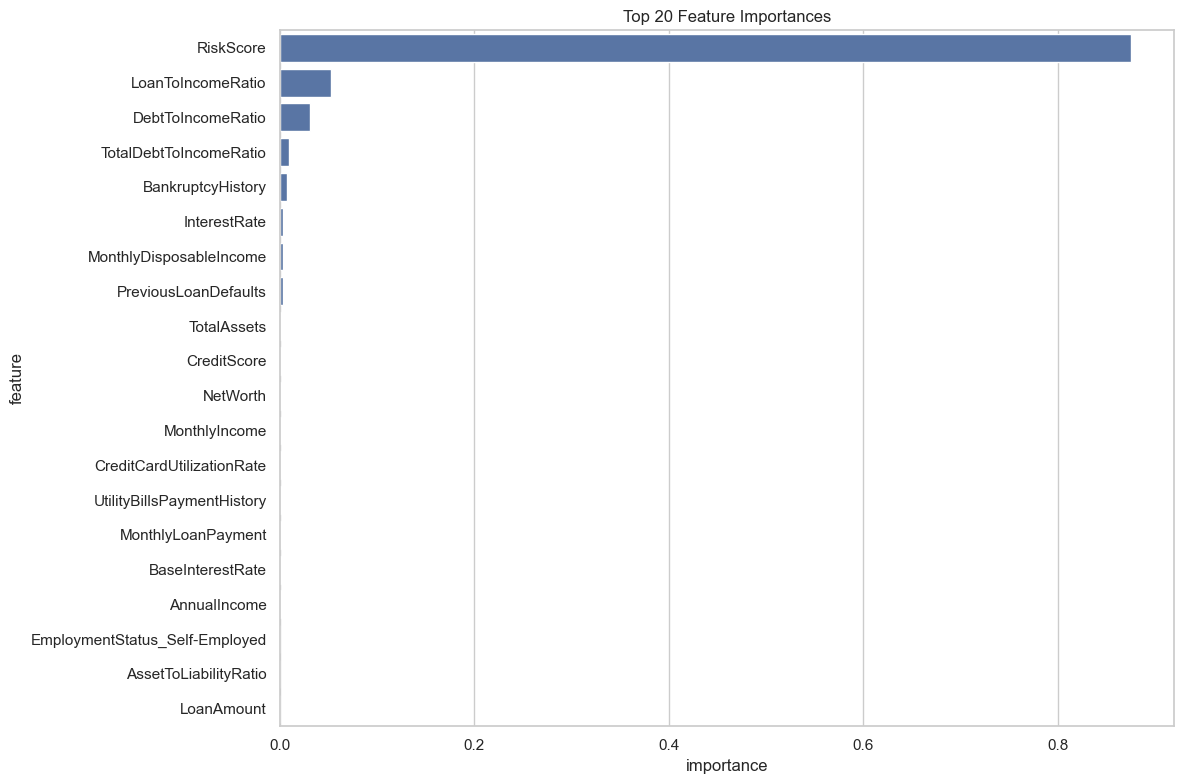

In [23]:
def get_feature_names(column_transformer):
    output_features = []
    for name, transformer, columns in column_transformer.transformers_:
        if name == "remainder" and transformer == "drop":
            continue
        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                names = last_step.get_feature_names_out(columns)
            else:
                names = columns
        elif hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(columns)
        else:
            names = columns
        output_features.extend(names)
    return np.array(output_features)

final_rf = best_model.named_steps["model"]
fitted_preprocessor = best_model.named_steps["preprocessor"]
feature_names = get_feature_names(fitted_preprocessor)

if hasattr(final_rf, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": final_rf.feature_importances_
    }).sort_values("importance", ascending=False)
    display(feature_importance.head(25))

    plt.figure(figsize=(12,8))
    sns.barplot(data=feature_importance.head(20), x="importance", y="feature")
    plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for the selected model.")

## Business Interpretation of Feature Importance

Important features are expected to include credit score, debt-to-income ratios, prior defaults, bankruptcy history, interest rate, payment history, income, net worth, and loan affordability measures. If these features rank highly, the model is using variables that are logically connected to credit-risk assessment.

The business should use these insights to strengthen underwriting policy, identify higher-risk profiles, and improve manual review guidelines.

## 10. Final Recommendations

1. **Use the model as decision support first**, not full automation.
2. **Prioritize business cost**, not accuracy alone.
3. **Use threshold bands**: low-risk applications can be fast-tracked, medium-risk applications reviewed manually, and high-risk applications escalated or declined.
4. **Monitor false approvals monthly** because they create the largest loss.
5. **Review model performance by segment** to detect possible instability or bias.
6. **Retrain periodically** as borrower behaviour and economic conditions change.
7. **Maintain model documentation** for audit, compliance, and governance purposes.

## Limitations and Potential Improvements

### Limitations

- The dataset may be synthetic or historically generated.
- Past loan decisions may contain historical bias.
- Correlation and feature importance do not prove causation.
- Economic conditions may change model performance over time.
- A single train-test split may not fully represent future production data.

### Improvements

- Add time-based validation if application dates are reliable.
- Test XGBoost or LightGBM if installed.
- Add SHAP values for deeper explainability.
- Conduct fairness testing before deployment.
- Set up drift monitoring after deployment.

# Conclusion

This notebook completed a CRISP-DM workflow for loan approval modelling. It defined the business problem, quantified the cost of errors, explored the dataset, built preprocessing pipelines using `ColumnTransformer` and `Pipeline`, compared several classification algorithms, tuned a Random Forest model, optimized the decision threshold, evaluated model performance, and translated the results into business actions.

The main conclusion is that lending models should be evaluated in business terms. Since false approvals are much more expensive than false rejections, the recommended model should minimize expected business cost while maintaining strong ROC-AUC, precision, recall, and explainability.